# Modelo CART — Análisis de Cartera
**Datos:** Diciembre 2025

In [ ]:
pip install seaborn

In [ ]:
import sys
!{sys.executable} -m pip install imbalanced-learn

In [103]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV  # generar grilla para CV
from imblearn.over_sampling import RandomOverSampler  # libreria para hacer oversample 
from sklearn.pipeline import Pipeline   # Construcción de flujos automáticos de preprocesamiento y modelos

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay,
                             average_precision_score, PrecisionRecallDisplay, f1_score)
from imblearn.over_sampling import SMOTE   # cambia a ADASYN si prefieres (ver nota abajo)
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score,
                             classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)
import matplotlib.pyplot as plt

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

pd.set_option('display.max_seq_items', 300)
pd.set_option('display.max_columns', 300)

RUTA = r'C:\Users\Usuario\OneDrive - Global Green Growth Institute\Documentos\Gadiel\Aplicacion\OneDrive_1_21-3-2026\nuevos'

# Archivos disponibles
print('Archivos en la carpeta:')
for f in os.listdir(RUTA):
    print(' -', f)

Archivos en la carpeta:
 - CalCartera_Analisis_UTRAHUILCA DIC2025.xlsx
 - CalCartera_Analisis_UTRAHUILCA_JUN2025.xlsx
 - Calificacion_Cartera_UTRA DIC 2025.xlsx
 - Calificacion_Cartera_UTRA JUN 2025.xlsx
 - Detalle tabla evaluación de cartera curuba.xlsx
 - feature_cols.pkl
 - Informe_Cartera_ENERO2026.xlsx
 - Informe_Cartera_MAYO2025.xlsx
 - Informe_Cartera_NOVIEMBRE2025.xlsx
 - Lógica de la metodologia.xlsx
 - median_train.pkl
 - pronostico_enero2026.xlsx
 - SALIDA PEC SALDOS JUNIO 2025.xlsx
 - SALIDA PEC SALDOS_DIC_2025.xlsx
 - VECTOR ENERO.xlsx
 - xgb_empeoro.pkl


## Categorías de riesgo y altura de mora por modalidad

| Categoría | Vivienda | Consumo | Microcrédito | Comercial |
|---|---|---|---|---|
| A — Normal | ≤ 60 días | ≤ 30 días | ≤ 30 días | ≤ 30 días |
| B — Aceptable | 61–150 días | 31–60 días | 31–60 días | 31–90 días |
| C — Apreciable | 151–360 días | 61–90 días | 61–90 días | 91–120 días |
| D — Significativo | 361–540 días | 91–180 días | 91–120 días | 121–150 días |
| E — Irrecuperable | > 540 días | > 180 días | > 120 días | > 150 días |

## Consideraciones clave para el modelo

1. **Variable objetivo (calificación):** el modelo debe predecir la categoría de riesgo A–E,
que se determina principalmente por la altura de mora, pero siempre tomando la
calificación de mayor riesgo entre todas las fuentes posibles.

2. **Deterioro como variable de salida:** si el modelo también estima provisiones, debes
parametrizar los porcentajes de deterioro diferenciados por modalidad (consumo,
comercial persona natural/jurídica, vivienda, microcrédito), incluyendo las subcategorías
E1 y E2.

3. **Variables relevantes para el modelo Logit:** altura de mora, modalidad de crédito,
tipo de persona (natural/jurídica), existencia y tipo de garantía (hipotecaria vs. no
hipotecaria), valor de aportes sociales, y condición de reestructuración.

4. **Regla del arrastre:** debes considerar que la calificación no es solo individual — si
un deudor tiene múltiples créditos de la misma modalidad, todos heredan la peor
calificación, lo que afecta la definición del incumplimiento en tu set de entrenamiento.

In [124]:
os.chdir("C:/Users/Usuario/OneDrive - Global Green Growth Institute/Documentos/Gadiel/Aplicacion/OneDrive_1_21-3-2026/nuevos")

In [125]:
os.listdir()

['CalCartera_Analisis_UTRAHUILCA DIC2025.xlsx',
 'CalCartera_Analisis_UTRAHUILCA_JUN2025.xlsx',
 'Calificacion_Cartera_UTRA DIC 2025.xlsx',
 'Calificacion_Cartera_UTRA JUN 2025.xlsx',
 'Detalle tabla evaluación de cartera curuba.xlsx',
 'feature_cols.pkl',
 'Informe_Cartera_ENERO2026.xlsx',
 'Informe_Cartera_MAYO2025.xlsx',
 'Informe_Cartera_NOVIEMBRE2025.xlsx',
 'Lógica de la metodologia.xlsx',
 'median_train.pkl',
 'pronostico_enero2026.xlsx',
 'pronostico_enero2026_II.xlsx',
 'SALIDA PEC SALDOS JUNIO 2025.xlsx',
 'SALIDA PEC SALDOS_DIC_2025.xlsx',
 'VECTOR ENERO.xlsx',
 'xgb_empeoro.pkl']

In [126]:
cartera_t=pd.read_excel("Informe_Cartera_NOVIEMBRE2025.xlsx",header=0)
cartera_t.head(3)

Exception ignored while calling deallocator <function ZipFile.__del__ at 0x0000022F94E1C1A0>:
Traceback (most recent call last):
  File "c:\Users\Usuario\AppData\Local\Python\pythoncore-3.14-64\Lib\zipfile\__init__.py", line 2059, in __del__
    self.close()
  File "c:\Users\Usuario\AppData\Local\Python\pythoncore-3.14-64\Lib\zipfile\__init__.py", line 2076, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


,VIGENCIA,MES,DÍA,CTVO,TIPO IDENTIFICACIÓN,IDETIFICACIÓN,CÓDIGO CONTABLE,MODIFICACIONES AL CRÉDITO,CRÉDITO,CODCUE,FECHA DESEMBOLSO,FECHA VENCIMIENTO,MOROSIDAD,TIPO CUOTA,CUOTAS PAGADAS,AMORTIZACIÓN,MODALIDAD,TASA INTERÉS NOMINAL,TASA INTERÉS EFECTIVA,VALOR PRÉSTAMO,VALOR CUOTA,SALDO CAPITAL,SALDO INTERESES,OTROS SALDOS,GARANTÍA,FECHA AVALÚO,DETERIORO,DETERIORO INTERESES,CONTINGENCIA,VALOR CUOTA EXTRA,MESES CUOTA EXTRA,FECHA ÚLTIMO PAGO,CLASE GARANTÍA,DESTINO CRÉDITO,CÓDIGO OFICINA,PERIODICIDAD AMORTIZACIÓN,VALOR MORA,TIPO VIVIENDA,SEÑAL VIS,TIPO O RANGO VIVIENDA,SEÑAL SUBSIDIO,ENTIDAD REDESCUENTO,MARGEN REDESCUENTO,DESEMBOLSO,MONEDA,FECHA MODIFICACIÓN,CALIFICACIÓN ANTES MODIFICACIÓN,VALOR APORTES SOCIALES,VALOR LÍNEA CRÉDITO,MODIFICACIONES,ESTADO CRÉDITO,NIT DEUDOR PATRONAL,NOMBRE DEUDOR PATRONAL,MODIFICACIONES DEL CRÉDITO CE 11/20,TIPO DE MODIFICACIÓN CE 11/20,FECHA DE MODIFICACIÓN CE 11/20,CALIFICACIÓN ANTES DE MODIFICACIÓN CE 11/20,PERIODO DE GRACIAS CE 11/20,TARJETA DE CREDITO O CUPO ROTATIVO,ENTIDAD DONDE SE OTORGÓ GARANTÍA,MODIFICACIONES AL CRÉDITO CE 17/20,ESTAMENTO DE APROBACIÓN,ACTIVIDAD ECONÓMICA DEUDOR,APLICA EXCEPCIÓN,CALIFICACIÓN,ARRASTRE,LÍNEA,ESTADO CARTERA,FORMA DE PAGO,TIPO DE CARTERA,CLASIFICACIÓN,DETALLE GARANTÍA,USUARIO ANALISTA,FECHA INICIO,FLUJO ESPECIAL,INGRESOS ACTUALES,INGRESOS AÑO ANTERIOR,ÚLTIMA ACTUALIZACIÓN DE DATOS,ACTIVOS,PASIVOS,SECTOR ECONOMICO,FECHA SIGUIENTE CUOTA
0,2025,11,30,1,C,6756937922,144205,4,157011094141,11094141,2014-08-22,2026-07-31,0,1,0,30,2,21.72,24.02,2000000,130000,988488,1773.0,0,0,00:00:00,6374.03,0.0,0,NaN,NaN,2025-11-27,15,O,1,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140390,CONSUMO - UTRAVANCE,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGENCIA,ASALARIADO,SIN EXCEPCIONES,A,A,570,VIGENTE,2,NUEVO,CONSUMO,0-SIN GARANTÍA,ND,2012-03-27,NO,3286000,2715200,2025-09-05,194579862.0,25000000.0,SECTOR ECONOMIA SOLIDARIA (NO FINANCIERO),2025-11-30
1,2025,11,30,2,C,1970447155,144205,4,157011105797,11105797,2014-08-21,2027-05-31,0,1,0,30,2,20.65,22.72,3000000,150000,2342610,40542.0,0,0,00:00:00,13014.11,0.0,0,NaN,NaN,2025-11-06,15,O,1,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,647938,CONSUMO - UTRAVANCE,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGENCIA,JUBILADO PENSIONADO,SIN EXCEPCIONES,A,A,570,VIGENTE,2,NUEVO,CONSUMO,0-SIN GARANTÍA,ND,2012-07-16,NO,4200000,3912553,2025-11-12,80000000.0,33300000.0,JUBILADOS PENSIONADOS,2025-11-30
2,2025,11,30,3,C,8894397144,144205,4,1157011110873,11110873,2014-01-13,2026-08-31,0,1,0,30,2,20.65,22.72,5500000,230000,1941949,34810.0,0,0,00:00:00,13771.99,0.0,0,NaN,NaN,2025-11-14,15,O,11,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140494,CONSUMO - UTRAVANCE,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGENCIA,ASALARIADO,SIN EXCEPCIONES,A,A,570,VIGENTE,2,NUEVO,CONSUMO,0-SIN GARANTÍA,ND,2012-07-17,NO,5127000,4071000,2026-03-06,360282332.0,152261000.0,SALUD,2025-11-30


1. Calificación de Cartera en centrales (54,384 clientes)

In [127]:
df_calif_t = pd.read_excel(
    os.path.join(RUTA, 'CalCartera_Analisis_UTRAHUILCA DIC2025.xlsx'),
    sheet_name='Analisis_Cal_Cartera'
)
print('Shape:', df_calif_t.shape)
print('\nColumnas:')
print(df_calif_t.columns.tolist())
df_calif_t.head(3)

Shape: (54384, 35)

Columnas:
['TIPO_ID', 'NUMERO_ID', 'NOMBRE', 'SALDO_TOTAL', 'SALDO_ENTIDAD', 'PARTICIPACIÓN_SALDO_ENTIDAD', 'CALIF_DE_ARRASTRE_SUPER_MAYOR_20%', 'PROVISION_CON_CALIFICACION_SUPER_MAYOR_20%', 'RANGO PARTICIPACIÓN ENTIDAD EN ENDEUDAMIENTO GLOBAL DEL CLIENTE', 'RANGO SALDO TOTAL CON ENTIDAD', 'RIESGO', 'Max_Fecha_Apert_Entidad', 'Max_Fecha_Apert_Mercado', 'Ant_Meses_Obl_Entidad', 'Ant_Meses_Obl_Mercado', 'Rango_Ant_Obl_Entidad', 'Rango_Ant_Obl_Mercado', 'SALDO_MERCADO', 'INSOLVENCIA', 'PROXIMO_INSOLVENCIA', 'Peor_Cal_Entidad', 'Peor_Cal_Mercado', 'Cuota_Entidad', 'Cuota_Mercado', 'ValorMora_Entidad', 'ValorMora_Mercado', 'CantObl_Mercado', 'AlturaMora_Entidad', 'AlturaMora_Mercado', 'SumaDeVALOR_MORA', 'RANGO SALDO TOTAL CON MERCADO', 'RangosAlturasMora_Mercado', 'RangosAlturasMora_Entidad', 'RangosNumOblMoraMDO', 'RangosNumOblMoraETD']


,TIPO_ID,NUMERO_ID,NOMBRE,SALDO_TOTAL,SALDO_ENTIDAD,PARTICIPACIÓN_SALDO_ENTIDAD,CALIF_DE_ARRASTRE_SUPER_MAYOR_20%,PROVISION_CON_CALIFICACION_SUPER_MAYOR_20%,RANGO PARTICIPACIÓN ENTIDAD EN ENDEUDAMIENTO GLOBAL DEL CLIENTE,RANGO SALDO TOTAL CON ENTIDAD,RIESGO,Max_Fecha_Apert_Entidad,Max_Fecha_Apert_Mercado,Ant_Meses_Obl_Entidad,Ant_Meses_Obl_Mercado,Rango_Ant_Obl_Entidad,Rango_Ant_Obl_Mercado,SALDO_MERCADO,INSOLVENCIA,PROXIMO_INSOLVENCIA,Peor_Cal_Entidad,Peor_Cal_Mercado,Cuota_Entidad,Cuota_Mercado,ValorMora_Entidad,ValorMora_Mercado,CantObl_Mercado,AlturaMora_Entidad,AlturaMora_Mercado,SumaDeVALOR_MORA,RANGO SALDO TOTAL CON MERCADO,RangosAlturasMora_Mercado,RangosAlturasMora_Entidad,RangosNumOblMoraMDO,RangosNumOblMoraETD
0,1,7434409712,NaN,10556,3034.0,0.29,A,0.0,MENOR AL 50%,ENTRE 2 Y 5M,Riesgo_Bajo,2024-08-30,2022-03-02,16.0,114.0,ENTRE 1 Y 2 AÑOS,MAYOR A TRES AÑOS,7522.0,0,0,A,A,224.0,590.0,0.0,0.0,1.0,Al Dia: 0 - 29 Dias,Al Dia: 0 - 29 Dias,0,ENTRE 5 Y 10M,1.0,1.0,0.0,0.0
1,1,218820678,NaN,44431,5593.0,0.13,A,0.0,MENOR AL 50%,ENTRE 5 Y 10M,Riesgo_Bajo,2024-04-05,2025-09-04,20.0,3.0,ENTRE 1 Y 2 AÑOS,MENOR A UN AÑO,38838.0,0,0,A,A,178.0,675.0,0.0,0.0,1.0,Al Dia: 0 - 29 Dias,Al Dia: 0 - 29 Dias,0,SUPERIOR A 25M,1.0,1.0,0.0,0.0
2,1,643449365,NaN,7247,4897.0,0.68,A,0.0,MAYOR O IGUAL AL 50%,ENTRE 2 Y 5M,Riesgo_Bajo,2023-11-05,2019-01-23,25.0,307.0,ENTRE 2 Y 3 AÑOS,MAYOR A TRES AÑOS,2350.0,0,0,A,A,242.0,295.0,0.0,0.0,1.0,Al Dia: 0 - 29 Dias,Al Dia: 0 - 29 Dias,0,ENTRE 2 Y 5M,1.0,1.0,0.0,0.0


2.CRUZAR DATAFRAME DE DATOS INTERNOS CON CALIFICACION DE CENTRALES

In [128]:
# Asegurar mismo tipo de dato
cartera_t["IDETIFICACIÓN"] = cartera_t["IDETIFICACIÓN"].astype(str)
df_calif_t["NUMERO_ID"] = df_calif_t["NUMERO_ID"].astype(str)
df_calif_t = df_calif_t.drop_duplicates(subset="NUMERO_ID")
data_final = cartera_t.merge(
    df_calif_t[[
    "NUMERO_ID",
    "CALIF_DE_ARRASTRE_SUPER_MAYOR_20%",
    "PROVISION_CON_CALIFICACION_SUPER_MAYOR_20%",
    "RANGO PARTICIPACIÓN ENTIDAD EN ENDEUDAMIENTO GLOBAL DEL CLIENTE",
    "RIESGO",
    "INSOLVENCIA",
    "PROXIMO_INSOLVENCIA",
    "Peor_Cal_Entidad",
    "Peor_Cal_Mercado",
    "ValorMora_Entidad",
    "ValorMora_Mercado",
    "RangosNumOblMoraMDO",
    "CantObl_Mercado",
]], 
    left_on="IDETIFICACIÓN",
    right_on="NUMERO_ID",
    how="left"
)
print(data_final.shape)

data_final_t=data_final[["CALIFICACIÓN","CODCUE"]]
data_final_t.head()

(57450, 95)


,CALIFICACIÓN,CODCUE
0,A,11094141
1,A,11105797
2,A,11110873
3,A,11107645
4,A,11110631


In [129]:
cartera_t_1 = pd.read_excel("Informe_Cartera_MAYO2025.xlsx", header=0)
cartera_t_1.head(3)

,VIGENCIA,MES,DÍA,CTVO,TIPO IDENTIFICACIÓN,IDETIFICACIÓN,CÓDIGO CONTABLE,MODIFICACIONES AL CRÉDITO,CRÉDITO,CODCUE,FECHA DESEMBOLSO,FECHA VENCIMIENTO,MOROSIDAD,TIPO CUOTA,CUOTAS PAGADAS,AMORTIZACIÓN,MODALIDAD,TASA INTERÉS NOMINAL,TASA INTERÉS EFECTIVA,VALOR PRÉSTAMO,VALOR CUOTA,SALDO CAPITAL,SALDO INTERESES,OTROS SALDOS,GARANTÍA,FECHA AVALÚO,DETERIORO,DETERIORO INTERESES,CONTINGENCIA,VALOR CUOTA EXTRA,MESES CUOTA EXTRA,FECHA ÚLTIMO PAGO,CLASE GARANTÍA,DESTINO CRÉDITO,CÓDIGO OFICINA,PERIODICIDAD AMORTIZACIÓN,VALOR MORA,TIPO VIVIENDA,SEÑAL VIS,TIPO O RANGO VIVIENDA,SEÑAL SUBSIDIO,ENTIDAD REDESCUENTO,MARGEN REDESCUENTO,DESEMBOLSO,MONEDA,FECHA MODIFICACIÓN,CALIFICACIÓN ANTES MODIFICACIÓN,VALOR APORTES SOCIALES,VALOR LÍNEA CRÉDITO,MODIFICACIONES,ESTADO CRÉDITO,NIT DEUDOR PATRONAL,NOMBRE DEUDOR PATRONAL,MODIFICACIONES DEL CRÉDITO CE 11/20,TIPO DE MODIFICACIÓN CE 11/20,FECHA DE MODIFICACIÓN CE 11/20,CALIFICACIÓN ANTES DE MODIFICACIÓN CE 11/20,PERIODO DE GRACIAS CE 11/20,TARJETA DE CREDITO O CUPO ROTATIVO,ENTIDAD DONDE SE OTORGÓ GARANTÍA,MODIFICACIONES AL CRÉDITO CE 17/20,ESTAMENTO DE APROBACIÓN,ACTIVIDAD ECONÓMICA DEUDOR,APLICA EXCEPCIÓN,CALIFICACIÓN,ARRASTRE,LÍNEA,ESTADO CARTERA,FORMA DE PAGO,TIPO DE CARTERA,CLASIFICACIÓN,DETALLE GARANTÍA,USUARIO ANALISTA,FECHA INICIO,FLUJO ESPECIAL,INGRESOS ACTUALES,INGRESOS AÑO ANTERIOR,ÚLTIMA ACTUALIZACIÓN DE DATOS,ACTIVOS,PASIVOS,SECTOR ECONOMICO,FECHA SIGUIENTE CUOTA
0,2025,5,31,1,C,6756937922,144205,4,157011094141,11094141,2014-08-22,2026-07-31,0,1,0,30,2,21.89,24.23,2000000,130000,1616075,30240.0,0,0,1900-01-01,11081.45,0.0,0,NaN,NaN,2025-05-15,15,O,1,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,168788,CONSUMO - UTRAVANCE,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGENCIA,ASALARIADO,SIN EXCEPCIONES,A,A,570,VIGENTE,2,NUEVO,CONSUMO,0-SIN GARANTÍA,ND,2012-03-27,NO,3286000,2715200,2025-09-05,194579862.0,25000000.0,SECTOR ECONOMIA SOLIDARIA (NO FINANCIERO),2025-05-31
1,2025,5,31,2,C,9567340268,144205,4,857011106182,11106182,2014-08-17,2027-09-30,0,1,0,30,2,21.89,24.23,4000000,180000,4007713,72974.0,0,0,1900-01-01,21170.37,0.0,0,NaN,NaN,2025-05-16,15,O,8,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1257971,CONSUMO - UTRAVANCE,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGENCIA,ASALARIADO,SIN EXCEPCIONES,A,A,570,VIGENTE,0,NUEVO,CONSUMO,0-SIN GARANTÍA,ND,2012-07-13,NO,2771424,2771424,2026-01-19,209133695.0,12785000.0,SECTOR ECONOMIA SOLIDARIA (NO FINANCIERO),2025-05-31
2,2025,5,31,3,C,1970447155,144205,4,157011105797,11105797,2014-08-21,2027-04-30,0,1,0,30,2,20.82,22.93,3000000,150000,2913246,50514.0,0,0,1900-01-01,16981.88,0.0,0,NaN,NaN,2025-05-02,15,O,1,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,699509,CONSUMO - UTRAVANCE,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGENCIA,JUBILADO PENSIONADO,SIN EXCEPCIONES,A,A,570,VIGENTE,2,NUEVO,CONSUMO,0-SIN GARANTÍA,ND,2012-07-16,NO,4200000,3912553,2025-11-12,80000000.0,33300000.0,JUBILADOS PENSIONADOS,2025-05-31


In [130]:
df_calif_t_1 = pd.read_excel(
    os.path.join(RUTA, 'CalCartera_Analisis_UTRAHUILCA_JUN2025.xlsx'),
    sheet_name='Analisis_Cal_Cartera'
)

print('Shape:', df_calif_t_1.shape)
print('\nColumnas:')
print(df_calif_t_1.columns.tolist())
df_calif_t_1.head(3)

Shape: (51589, 35)

Columnas:
['TIPO_ID', 'NUMERO_ID', 'NOMBRE', 'SALDO_TOTAL', 'SALDO_ENTIDAD', 'PARTICIPACIÓN_SALDO_ENTIDAD', 'CALIF_DE_ARRASTRE_SUPER_MAYOR_20%', 'PROVISION_CON_CALIFICACION_SUPER_MAYOR_20%', 'RANGO PARTICIPACIÓN ENTIDAD EN ENDEUDAMIENTO GLOBAL DEL CLIENTE', 'RANGO SALDO TOTAL CON ENTIDAD', 'RIESGO', 'Max_Fecha_Apert_Entidad', 'Max_Fecha_Apert_Mercado', 'Ant_Meses_Obl_Entidad', 'Ant_Meses_Obl_Mercado', 'Rango_Ant_Obl_Entidad', 'Rango_Ant_Obl_Mercado', 'SALDO_MERCADO', 'INSOLVENCIA', 'PROXIMO_INSOLVENCIA', 'Peor_Cal_Entidad', 'Peor_Cal_Mercado', 'Cuota_Entidad', 'Cuota_Mercado', 'ValorMora_Entidad', 'ValorMora_Mercado', 'CantObl_Mercado', 'AlturaMora_Entidad', 'AlturaMora_Mercado', 'SumaDeVALOR_MORA', 'RANGO SALDO TOTAL CON MERCADO', 'RangosAlturasMora_Mercado', 'RangosAlturasMora_Entidad', 'RangosNumOblMoraMDO', 'RangosNumOblMoraETD']


,TIPO_ID,NUMERO_ID,NOMBRE,SALDO_TOTAL,SALDO_ENTIDAD,PARTICIPACIÓN_SALDO_ENTIDAD,CALIF_DE_ARRASTRE_SUPER_MAYOR_20%,PROVISION_CON_CALIFICACION_SUPER_MAYOR_20%,RANGO PARTICIPACIÓN ENTIDAD EN ENDEUDAMIENTO GLOBAL DEL CLIENTE,RANGO SALDO TOTAL CON ENTIDAD,RIESGO,Max_Fecha_Apert_Entidad,Max_Fecha_Apert_Mercado,Ant_Meses_Obl_Entidad,Ant_Meses_Obl_Mercado,Rango_Ant_Obl_Entidad,Rango_Ant_Obl_Mercado,SALDO_MERCADO,INSOLVENCIA,PROXIMO_INSOLVENCIA,Peor_Cal_Entidad,Peor_Cal_Mercado,Cuota_Entidad,Cuota_Mercado,ValorMora_Entidad,ValorMora_Mercado,CantObl_Mercado,AlturaMora_Entidad,AlturaMora_Mercado,SumaDeVALOR_MORA,RANGO SALDO TOTAL CON MERCADO,RangosAlturasMora_Mercado,RangosAlturasMora_Entidad,RangosNumOblMoraMDO,RangosNumOblMoraETD
0,1,7434409712,NaN,15200,3786.0,0.25,A,0.0,MENOR AL 50%,ENTRE 2 Y 5M,Riesgo_Bajo,2024-08-30,2022-03-02,10.0,108.0,MENOR A UN AÑO,MAYOR A TRES AÑOS,11414.0,0,0,A,A,224.0,648.0,0.0,0.0,1.0,Al Dia: 0 - 29 Dias,Al Dia: 0 - 29 Dias,0,ENTRE 10 Y 25M,1.0,1.0,0.0,0.0
1,1,218820678,NaN,9476,6454.0,0.68,A,0.0,MAYOR O IGUAL AL 50%,ENTRE 5 Y 10M,Riesgo_Bajo,2024-04-05,2019-08-15,14.0,70.0,ENTRE 1 Y 2 AÑOS,MAYOR A TRES AÑOS,3022.0,0,0,A,A,205.0,657.0,0.0,0.0,1.0,Al Dia: 0 - 29 Dias,Al Dia: 0 - 29 Dias,0,ENTRE 2 Y 5M,1.0,1.0,0.0,0.0
2,1,643449365,NaN,9183,5985.0,0.65,A,0.0,MAYOR O IGUAL AL 50%,ENTRE 5 Y 10M,Riesgo_Bajo,2023-11-05,2019-01-23,19.0,301.0,ENTRE 1 Y 2 AÑOS,MAYOR A TRES AÑOS,3198.0,0,0,A,A,242.0,322.0,0.0,0.0,1.0,Al Dia: 0 - 29 Dias,Al Dia: 0 - 29 Dias,0,ENTRE 2 Y 5M,1.0,1.0,0.0,0.0


In [131]:
cartera_t_1["IDETIFICACIÓN"] = cartera_t_1["IDETIFICACIÓN"].astype(str)
df_calif_t_1["NUMERO_ID"] = df_calif_t_1["NUMERO_ID"].astype(str)
df_calif_t_1 = df_calif_t_1.drop_duplicates(subset="NUMERO_ID")

data_final_t_1 = cartera_t_1.merge(
    df_calif_t_1[[
        "NUMERO_ID",
    "CALIF_DE_ARRASTRE_SUPER_MAYOR_20%",
    "PROVISION_CON_CALIFICACION_SUPER_MAYOR_20%",
    "RANGO PARTICIPACIÓN ENTIDAD EN ENDEUDAMIENTO GLOBAL DEL CLIENTE",
    "RIESGO",
    "INSOLVENCIA",
    "PROXIMO_INSOLVENCIA",
    "Peor_Cal_Entidad",
    "Peor_Cal_Mercado",
    "ValorMora_Entidad",
    "ValorMora_Mercado",
    "RangosNumOblMoraMDO",
    "CantObl_Mercado",
    ]],
    left_on="IDETIFICACIÓN",
    right_on="NUMERO_ID",
    how="left"
)
data_final_t_1=data_final_t_1.merge(data_final_t, on="CODCUE", how="inner")
data_final_t_1.head(2)

,VIGENCIA,MES,DÍA,CTVO,TIPO IDENTIFICACIÓN,IDETIFICACIÓN,CÓDIGO CONTABLE,MODIFICACIONES AL CRÉDITO,CRÉDITO,CODCUE,FECHA DESEMBOLSO,FECHA VENCIMIENTO,MOROSIDAD,TIPO CUOTA,CUOTAS PAGADAS,AMORTIZACIÓN,MODALIDAD,TASA INTERÉS NOMINAL,TASA INTERÉS EFECTIVA,VALOR PRÉSTAMO,VALOR CUOTA,SALDO CAPITAL,SALDO INTERESES,OTROS SALDOS,GARANTÍA,FECHA AVALÚO,DETERIORO,DETERIORO INTERESES,CONTINGENCIA,VALOR CUOTA EXTRA,MESES CUOTA EXTRA,FECHA ÚLTIMO PAGO,CLASE GARANTÍA,DESTINO CRÉDITO,CÓDIGO OFICINA,PERIODICIDAD AMORTIZACIÓN,VALOR MORA,TIPO VIVIENDA,SEÑAL VIS,TIPO O RANGO VIVIENDA,SEÑAL SUBSIDIO,ENTIDAD REDESCUENTO,MARGEN REDESCUENTO,DESEMBOLSO,MONEDA,FECHA MODIFICACIÓN,CALIFICACIÓN ANTES MODIFICACIÓN,VALOR APORTES SOCIALES,VALOR LÍNEA CRÉDITO,MODIFICACIONES,ESTADO CRÉDITO,NIT DEUDOR PATRONAL,NOMBRE DEUDOR PATRONAL,MODIFICACIONES DEL CRÉDITO CE 11/20,TIPO DE MODIFICACIÓN CE 11/20,FECHA DE MODIFICACIÓN CE 11/20,CALIFICACIÓN ANTES DE MODIFICACIÓN CE 11/20,PERIODO DE GRACIAS CE 11/20,TARJETA DE CREDITO O CUPO ROTATIVO,ENTIDAD DONDE SE OTORGÓ GARANTÍA,MODIFICACIONES AL CRÉDITO CE 17/20,ESTAMENTO DE APROBACIÓN,ACTIVIDAD ECONÓMICA DEUDOR,APLICA EXCEPCIÓN,CALIFICACIÓN_x,ARRASTRE,LÍNEA,ESTADO CARTERA,FORMA DE PAGO,TIPO DE CARTERA,CLASIFICACIÓN,DETALLE GARANTÍA,USUARIO ANALISTA,FECHA INICIO,FLUJO ESPECIAL,INGRESOS ACTUALES,INGRESOS AÑO ANTERIOR,ÚLTIMA ACTUALIZACIÓN DE DATOS,ACTIVOS,PASIVOS,SECTOR ECONOMICO,FECHA SIGUIENTE CUOTA,NUMERO_ID,CALIF_DE_ARRASTRE_SUPER_MAYOR_20%,PROVISION_CON_CALIFICACION_SUPER_MAYOR_20%,RANGO PARTICIPACIÓN ENTIDAD EN ENDEUDAMIENTO GLOBAL DEL CLIENTE,RIESGO,INSOLVENCIA,PROXIMO_INSOLVENCIA,Peor_Cal_Entidad,Peor_Cal_Mercado,ValorMora_Entidad,ValorMora_Mercado,RangosNumOblMoraMDO,CantObl_Mercado,CALIFICACIÓN_y
0,2025,5,31,1,C,6756937922,144205,4,157011094141,11094141,2014-08-22,2026-07-31,0,1,0,30,2,21.89,24.23,2000000,130000,1616075,30240.0,0,0,1900-01-01,11081.45,0.0,0,NaN,NaN,2025-05-15,15,O,1,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,168788,CONSUMO - UTRAVANCE,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGENCIA,ASALARIADO,SIN EXCEPCIONES,A,A,570,VIGENTE,2,NUEVO,CONSUMO,0-SIN GARANTÍA,ND,2012-03-27,NO,3286000,2715200,2025-09-05,194579862.0,25000000.0,SECTOR ECONOMIA SOLIDARIA (NO FINANCIERO),2025-05-31,6756937922,A,0.0,MAYOR O IGUAL AL 50%,Riesgo_Bajo,0.0,0.0,A,A,0.0,0.0,0.0,1.0,A
1,2025,5,31,3,C,1970447155,144205,4,157011105797,11105797,2014-08-21,2027-04-30,0,1,0,30,2,20.82,22.93,3000000,150000,2913246,50514.0,0,0,1900-01-01,16981.88,0.0,0,NaN,NaN,2025-05-02,15,O,1,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,699509,CONSUMO - UTRAVANCE,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGENCIA,JUBILADO PENSIONADO,SIN EXCEPCIONES,A,A,570,VIGENTE,2,NUEVO,CONSUMO,0-SIN GARANTÍA,ND,2012-07-16,NO,4200000,3912553,2025-11-12,80000000.0,33300000.0,JUBILADOS PENSIONADOS,2025-05-31,1970447155,A,0.0,MAYOR O IGUAL AL 50%,Riesgo_Bajo,0.0,0.0,A,A,0.0,991.0,1.0,1.0,A


In [132]:
orden_calif = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5}

data_final_t_1['calif_x_num'] = data_final_t_1['CALIFICACIÓN_x'].map(orden_calif)
data_final_t_1['calif_y_num'] = data_final_t_1['CALIFICACIÓN_y'].map(orden_calif)

def clasificar_cambio(row):
    if pd.isna(row['calif_x_num']) or pd.isna(row['calif_y_num']):
        return None
    if row['calif_y_num'] > row['calif_x_num']:
        return 'Empeoró'
    elif row['calif_y_num'] < row['calif_x_num']:
        return 'Mejoró'
    else:
        return 'Se mantuvo'

data_final_t_1['cambio_calificacion'] = data_final_t_1.apply(clasificar_cambio, axis=1)

# Dicotómica: 1 = empeoró, 0 = no empeoró
data_final_t_1['empeoro'] = (data_final_t_1['cambio_calificacion'] == 'Empeoró').astype(int)

print(data_final_t_1['cambio_calificacion'].value_counts())
print(data_final_t_1['empeoro'].value_counts(100))

cambio_calificacion
Se mantuvo    39691
Empeoró        2023
Mejoró          373
Name: count, dtype: int64
empeoro
0    0.951933
1    0.048067
Name: proportion, dtype: float64


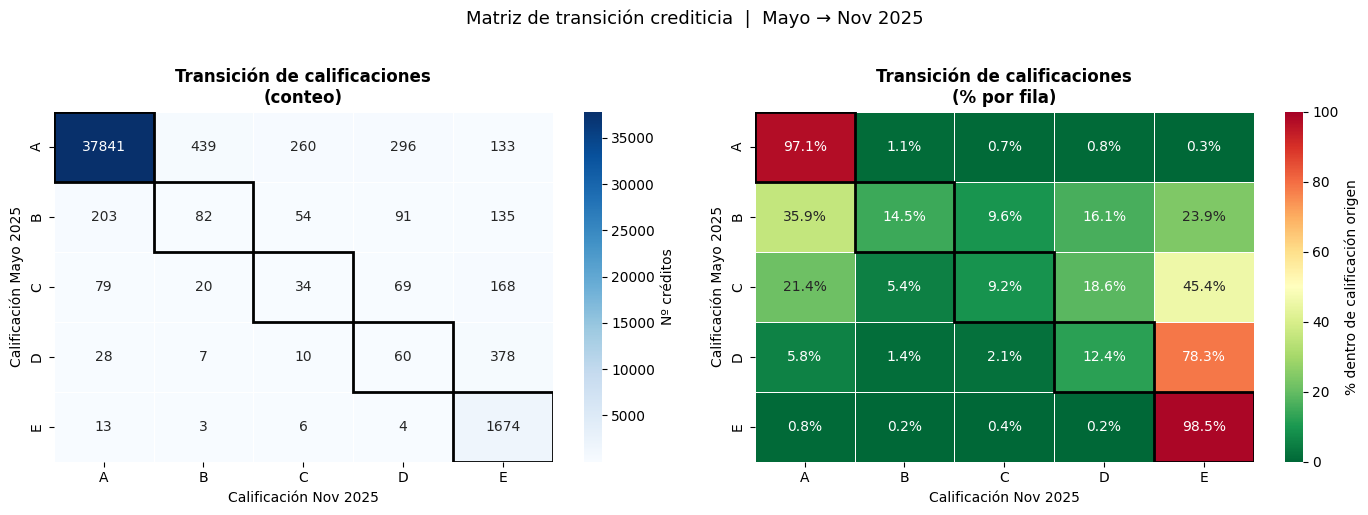

=== Flujos de deterioro (empeoró) ===
CALIFICACIÓN_x CALIFICACIÓN_y   n
             A              B 439
             D              E 378
             A              D 296
             A              C 260
             C              E 168
             B              E 135
             A              E 133
             B              D  91
             C              D  69
             B              C  54


In [133]:


califs = ['A', 'B', 'C', 'D', 'E']

# Matriz de transición (solo filas con ambas calificaciones)
df_trans = data_final_t_1.dropna(subset=['CALIFICACIÓN_x', 'CALIFICACIÓN_y'])
df_trans = df_trans[df_trans['CALIFICACIÓN_x'].isin(califs) & df_trans['CALIFICACIÓN_y'].isin(califs)]

matriz = pd.crosstab(
    df_trans['CALIFICACIÓN_x'],
    df_trans['CALIFICACIÓN_y'],
    rownames=['Mayo 2025'],
    colnames=['Nov 2025']
).reindex(index=califs, columns=califs, fill_value=0)

# Porcentaje por fila (de dónde vino cada calificación)
matriz_pct = matriz.div(matriz.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Heatmap conteos ---
sns.heatmap(
    matriz, ax=axes[0],
    annot=True, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Nº créditos'}
)
axes[0].set_title('Transición de calificaciones\n(conteo)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Calificación Nov 2025')
axes[0].set_ylabel('Calificación Mayo 2025')

# --- Heatmap % por fila ---
annot_pct = matriz_pct.map(lambda x: f'{x:.1f}%')
sns.heatmap(
    matriz_pct, ax=axes[1],
    annot=annot_pct, fmt='', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    vmin=0, vmax=100,
    cbar_kws={'label': '% dentro de calificación origen'}
)
axes[1].set_title('Transición de calificaciones\n(% por fila)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Calificación Nov 2025')
axes[1].set_ylabel('Calificación Mayo 2025')

# Resaltar diagonal (se mantuvo)
for ax in axes:
    for i in range(len(califs)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='black', lw=2))

plt.suptitle('Matriz de transición crediticia  |  Mayo → Nov 2025', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Resumen textual ---
print("=== Flujos de deterioro (empeoró) ===")
deterioro = df_trans[df_trans['CALIFICACIÓN_y'] > df_trans['CALIFICACIÓN_x'].map(
    lambda x: califs[califs.index(x)] if x in califs else x
)]
flujos = (df_trans[df_trans['cambio_calificacion'] == 'Empeoró']
          .groupby(['CALIFICACIÓN_x', 'CALIFICACIÓN_y'])
          .size().reset_index(name='n')
          .sort_values('n', ascending=False))
print(flujos.to_string(index=False))

In [134]:
data_final_t_1.columns.to_list()

['VIGENCIA',
 'MES',
 'DÍA',
 'CTVO',
 'TIPO IDENTIFICACIÓN',
 'IDETIFICACIÓN',
 'CÓDIGO CONTABLE',
 'MODIFICACIONES AL CRÉDITO',
 'CRÉDITO',
 'CODCUE',
 'FECHA DESEMBOLSO',
 'FECHA VENCIMIENTO',
 'MOROSIDAD',
 'TIPO CUOTA',
 'CUOTAS PAGADAS',
 'AMORTIZACIÓN',
 'MODALIDAD',
 'TASA INTERÉS NOMINAL',
 'TASA INTERÉS EFECTIVA',
 'VALOR PRÉSTAMO',
 'VALOR CUOTA',
 'SALDO CAPITAL',
 'SALDO INTERESES',
 'OTROS SALDOS',
 'GARANTÍA',
 'FECHA AVALÚO',
 'DETERIORO',
 'DETERIORO INTERESES',
 'CONTINGENCIA',
 'VALOR CUOTA EXTRA',
 'MESES CUOTA EXTRA',
 'FECHA ÚLTIMO PAGO',
 'CLASE GARANTÍA',
 'DESTINO CRÉDITO',
 'CÓDIGO OFICINA',
 'PERIODICIDAD AMORTIZACIÓN',
 'VALOR MORA',
 'TIPO VIVIENDA',
 'SEÑAL VIS ',
 'TIPO O RANGO VIVIENDA',
 'SEÑAL SUBSIDIO',
 'ENTIDAD REDESCUENTO',
 'MARGEN REDESCUENTO',
 'DESEMBOLSO',
 'MONEDA',
 'FECHA MODIFICACIÓN',
 'CALIFICACIÓN ANTES MODIFICACIÓN',
 'VALOR APORTES SOCIALES',
 'VALOR LÍNEA CRÉDITO',
 'MODIFICACIONES',
 'ESTADO CRÉDITO',
 'NIT DEUDOR PATRONAL',
 'NOMBR

In [155]:
df = data_final_t_1.copy()

# ── 1. CAPACIDAD DE PAGO ──────────────────────────────────────────────────────

# --- 1.1 Relación Cuota / Ingreso (RCI) --------------------------------------
# Mide qué proporción del ingreso mensual se destina al servicio de la deuda.
# Umbral crítico CBCF: >30% representa carga excesiva.
df['RCI'] = np.where(
    df['INGRESOS ACTUALES'] > 0,
    df['VALOR CUOTA'] / df['INGRESOS ACTUALES'],
    np.nan
)

# --- 1.2 Carga Financiera Total (CFT) ----------------------------------------
# Incluye capital + intereses pendientes vs ingreso.
df['CFT'] = np.where(
    df['INGRESOS ACTUALES'] > 0,
    (df['VALOR CUOTA'] + df['SALDO INTERESES']) / df['INGRESOS ACTUALES'],
    np.nan
)

# --- 1.3 Variación de Ingresos (VI) ------------------------------------------
# Detecta deterioro o mejora en la capacidad generadora de flujo del deudor.
df['VI'] = np.where(
    df['INGRESOS AÑO ANTERIOR'] > 0,
    (df['INGRESOS ACTUALES'] - df['INGRESOS AÑO ANTERIOR']) / df['INGRESOS AÑO ANTERIOR'],
    np.nan
)

# --- 1.4 Patrimonio Neto (PN) -------------------------------------------------
df['PN'] = df['ACTIVOS'] - df['PASIVOS']

# --- 1.5 Nivel de Endeudamiento Total (NET) ----------------------------------
# Pasivos sobre Activos. >70% es señal de alerta.
df['NET'] = np.where(
    df['ACTIVOS'] > 0,
    df['PASIVOS'] / df['ACTIVOS'],
    np.nan
)

# --- 1.6 Relación Deuda Entidad / Patrimonio (RDP) ---------------------------
# Cuánto del saldo con la entidad representa respecto al patrimonio neto.
df['RDP'] = np.where(
    df['PN'] > 0,
    (df['SALDO CAPITAL'] + df['SALDO INTERESES']) / df['PN'],
    np.nan
)

# --- 1.7 Cobertura de Deuda (CD) ---------------------------------------------
# Veces que el ingreso cubre la deuda total con la entidad.
# CD < 1 → el ingreso anual no alcanza para cubrir el saldo total.
deuda_total = df['SALDO CAPITAL'] + df['SALDO INTERESES'] + df['OTROS SALDOS']
df['CD'] = np.where(
    deuda_total > 0,
    df['INGRESOS ACTUALES'] / deuda_total,
    np.nan
)

# --- 1.8 Señal de Ingreso Insuficiente (SII) ---------------------------------
# Bandera binaria: 1 si RCI > 0.30 o ingresos no cubren la cuota mínima.
df['SII'] = np.where(
    (df['RCI'] > 0.30) | (df['INGRESOS ACTUALES'] < df['VALOR CUOTA']),
    1, 0
)

# ── IMPUTACIÓN DE VALORES MÁXIMOS AL PERCENTIL 0.99 ─────────────────────────

cols_cp = ['RCI', 'CFT', 'VI', 'PN', 'NET', 'RDP', 'CD']

for col in cols_cp:
    p97 = df[col].quantile(0.97)
    df[col] = df[col].clip(upper=p97)

# --- 1.9 Score Capacidad de Pago (Score_CP) ----------------------------------
# Puntaje ordinal simple (0-4) para alimentar el modelo interno de PI.
# A mayor score, mayor deterioro en capacidad de pago.
df['Score_CP'] = (
    (df['RCI']  > 0.30).astype(int) +
    (df['CFT']  > 0.40).astype(int) +
    (df['NET']  > 0.70).astype(int) +
    (df['VI']   < 0.00).astype(int)   # ingreso cayó vs año anterior
)

# ── Verificación rápida ───────────────────────────────────────────────────────
cols_cp = ['RCI', 'CFT', 'VI', 'PN', 'NET', 'RDP', 'CD', 'SII', 'Score_CP']
print(df[cols_cp].describe().round(4))
print("\nDistribución Score_CP:\n", df['Score_CP'].value_counts().sort_index())


              RCI         CFT          VI            PN         NET  \
count  41933.0000  41933.0000  41939.0000  4.208700e+04  41936.0000   
mean       0.1630      0.2046      0.0746  9.452757e+07      0.3166   
std        0.1567      0.2033      0.2774  1.132485e+08      0.4732   
min        0.0003      0.0003     -1.0000 -2.811513e+09      0.0000   
25%        0.0619      0.0731      0.0000  1.000000e+07      0.0372   
50%        0.1152      0.1388      0.0000  6.250000e+07      0.1348   
75%        0.2002      0.2524      0.0000  1.428661e+08      0.3812   
max        0.7259      0.9286      1.1832  4.496138e+08      2.1764   

              RDP          CD         SII    Score_CP  
count  38751.0000  42087.0000  42087.0000  42087.0000  
mean       0.3630      0.9065      0.1333      0.4231  
std        0.6446      1.0336      0.3399      0.7377  
min        0.0000      0.0000      0.0000      0.0000  
25%        0.0407      0.2632      0.0000      0.0000  
50%        0.1014      0

In [156]:
# ── 2. SOLVENCIA DEL DEUDOR ──────────────────────────────────────────────────

# --- 2.1 Ratio de Solvencia (RS) ---------------------------------------------
# Activos sobre pasivos. RS < 1 = patrimonio negativo (insolvente técnico).
df['RS'] = np.where(
    df['PASIVOS'] > 0,
    df['ACTIVOS'] / df['PASIVOS'],
    np.nan
)

# --- 2.2 Cobertura de Activos sobre Deuda Entidad (CA) ----------------------
# Cuántas veces los activos cubren la deuda total con la entidad.
deuda_entidad = df['SALDO CAPITAL'] + df['SALDO INTERESES'] + df['OTROS SALDOS']
df['CA'] = np.where(
    deuda_entidad > 0,
    df['ACTIVOS'] / deuda_entidad,
    np.nan
)

# --- 2.3 Aportes Sociales / Saldo Capital (AS_SC) ---------------------------
# Relevante para cooperativas: mide respaldo patrimonial del asociado.
df['AS_SC'] = np.where(
    df['SALDO CAPITAL'] > 0,
    df['VALOR APORTES SOCIALES'] / df['SALDO CAPITAL'],
    np.nan
)

# --- Imputación P99 ----------------------------------------------------------
cols_sol = ['RS', 'CA', 'AS_SC']
for col in cols_sol:
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=p99)

# --- 2.4 Score Solvencia (Score_Sol) ----------------------------------------
# Usa también INSOLVENCIA si ya viene como flag en el DF
df['Score_Sol'] = (
    (df['RS']    < 1.0).astype(int) +   # pasivos > activos
    (df['CA']    < 1.0).astype(int) +   # activos no cubren deuda entidad
    (df['AS_SC'] < 0.3).astype(int) +   # aportes < 30% del saldo
    (df['INSOLVENCIA'] == 1).astype(int) if 'INSOLVENCIA' in df.columns
    else (df['RS'] < 0.5).astype(int)   # fallback si no existe la columna
)

print(df[cols_sol + ['Score_Sol']].describe().round(4))
print("\nDistribución Score_Sol:\n", df['Score_Sol'].value_counts().sort_index())

               RS          CA       AS_SC   Score_Sol
count  37247.0000  42087.0000  42087.0000  42087.0000
mean      22.4720     22.0456      0.2659      0.9852
std       62.4191     31.5340      0.3387      0.6920
min        0.0000      0.0000      0.0000      0.0000
25%        2.3012      3.4224      0.0782      1.0000
50%        5.8607     10.8000      0.1476      1.0000
75%       15.4992     26.5706      0.2888      1.0000
max      491.0796    187.8276      1.8835      4.0000

Distribución Score_Sol:
 Score_Sol
0     8694
1    26879
2     5097
3     1276
4      141
Name: count, dtype: int64


In [ ]:
# ── 3. GARANTÍAS ─────────────────────────────────────────────────────────────
from datetime import datetime

fecha_corte = pd.to_datetime(df[['VIGENCIA','MES','DÍA']].rename(
    columns={'VIGENCIA':'year','MES':'month','DÍA':'day'}))

# --- 3.1 Cobertura de Garantía (CG) -----------------------------------------
# Valor garantía / saldo capital. CG >= 1 → garantía cubre la obligación.
df['CG'] = np.where(
    df['SALDO CAPITAL'] > 0,
    df['GARANTÍA'] / df['SALDO CAPITAL'],
    np.nan
)
df['CG'] = df['CG'].clip(upper=df['CG'].quantile(0.99))



# --- 3.2 Garantía Admisible según circular (GA) ------------------------------
# Admisibles: dan preferencia jurídica real al acreedor
# No admisibles: sin garantía, codeudor personal, CDAT propio de la entidad


## En vez de adminisbles cambiar a idoneo y no idoneo, falta agregar CDAT UTRAHUILCA 
## Falta un FNG, CREDITO PARA CONOCERNOS

admisibles = [
    '1-HIPOTECA',
    '5-PRENDARIA',
    '6-CERTIFICADO GARANTIAS(FRGT)',
    '2-APORTES SOCIALES',
    '11-FAG',
    '16-FONDO DE GARANTIAS(FAG ESPECIA',
    '17-FNG (Unidos por el cambio EMP3',
    '14-PIGNORACION DE CONTRATOS',
    '12-CESION DE DERECHOS'
]

# CDAT UTRAHUILCA → NO admisible: CDT emitido por la propia entidad (circular)
# CODEUDOR → NO admisible: garantía personal, no otorga preferencia jurídica real
# SIN GARANTÍA → NO admisible

df['GA'] = np.where(
    df['DETALLE GARANTÍA'].astype(str).str.strip().isin(admisibles),
    1, 0
)

# --- 3.3 Antigüedad del Avalúo en meses (AA) --------------------------------
# Avalúos muy antiguos pierden vigencia técnica (criterio objetivo de valor).
df['FECHA AVALÚO'] = pd.to_datetime(df['FECHA AVALÚO'], errors='coerce')
df['AA'] = ((fecha_corte - df['FECHA AVALÚO']).dt.days / 30).round(1)
df['AA'] = df['AA'].clip(lower=0, upper=df['AA'].quantile(0.99))

# --- Score_Gar revisado: penalización condicional ---------------------------

# CG solo aplica si la garantía es admisible (tiene valor que evaluar)
penaliza_CG = ((df['GA'] == 1) & (df['CG'] < 1.0)).astype(int)

# AA solo aplica si la garantía es admisible y tiene fecha de avalúo
penaliza_AA = ((df['GA'] == 1) & (df['AA'] > 48)).astype(int)  # 4 años, más laxo

# GA=0 aporta 1 punto (no admisible), pero no acumula CG ni AA
df['Score_Gar'] = (
    (df['GA'] == 0).astype(int) +   # sin garantía admisible
    penaliza_CG +                    # garantía admisible pero no cubre
    penaliza_AA                      # garantía admisible pero avalúo vencido
)

print("Distribución Score_Gar revisado:\n", df['Score_Gar'].value_counts().sort_index())
print("\nCruce GA vs Score_Gar:\n", pd.crosstab(df['GA'], df['Score_Gar']))


Distribución Score_Gar revisado:
 Score_Gar
0      173
1    13046
2    28868
Name: count, dtype: int64

Cruce GA vs Score_Gar:
 Score_Gar    0      1      2
GA                          
0            0  12464      0
1          173    582  28868


In [158]:
# ── 4. SERVICIO DE LA DEUDA ──────────────────────────────────────────────────

# --- 4.1 Días de Mora (DM) ---------------------------------------------------
df['DM'] = pd.to_numeric(df['MOROSIDAD'], errors='coerce').clip(lower=0)

# --- 4.2 Días desde Último Pago (DSP) ----------------------------------------
df['FECHA ÚLTIMO PAGO'] = pd.to_datetime(df['FECHA ÚLTIMO PAGO'], errors='coerce')
df['DSP'] = ((fecha_corte - df['FECHA ÚLTIMO PAGO']).dt.days).clip(lower=0)
df['DSP'] = df['DSP'].clip(upper=df['DSP'].quantile(0.99))

# --- Score Servicio de la Deuda (Score_SD) -----------------------------------
df['Score_SD'] = (
    (df['DM']  > 30).astype(int) +
    (df['DM']  > 90).astype(int) +
    (df['DSP'] > 60).astype(int)
)

cols_sd = ['DM', 'DSP', 'Score_SD']
print(df[cols_sd].describe().round(4))
print("\nDistribución Score_SD:\n", df['Score_SD'].value_counts().sort_index())

               DM         DSP    Score_SD
count  42087.0000  42087.0000  42087.0000
mean      18.9154     32.9835      0.2494
std       86.7557     53.6017      0.6968
min        0.0000      0.0000      0.0000
25%        0.0000      5.0000      0.0000
50%        0.0000     18.0000      0.0000
75%        0.0000     28.0000      0.0000
max     3406.0000    333.0000      3.0000

Distribución Score_SD:
 Score_SD
0    36035
1     3445
2      771
3     1836
Name: count, dtype: int64


In [159]:
# ── 5. REESTRUCTURACIONES ────────────────────────────────────────────────────

# --- 5.1 Tiene Modificación al Crédito (MOD) --------------------------------
df['MOD'] = (pd.to_numeric(df['MODIFICACIONES'], errors='coerce').fillna(0) > 0).astype(int)

# --- 5.2 Modificaciones CE 11/20 y CE 17/20 (crisis/emergencia) --------------
df['MOD_CE'] = (
    (df['MODIFICACIONES DEL CRÉDITO CE 11/20'].astype(str).str.strip() != '0') &
    (df['MODIFICACIONES DEL CRÉDITO CE 11/20'].astype(str).str.strip() != 'nan')
).astype(int) | (
    (df['MODIFICACIONES AL CRÉDITO CE 17/20'].astype(str).str.strip() != '0') &
    (df['MODIFICACIONES AL CRÉDITO CE 17/20'].astype(str).str.strip() != 'nan')
).astype(int)

# --- 5.3 Deterioro de Calificación post-modificación (DET_MOD) --------------
# Si la calificación empeoró después de una reestructuración → señal crítica
df['DET_MOD'] = (
    (df['MOD'] == 1) & (df['empeoro'] == 1)
).astype(int)

# --- 5.4 Score Reestructuraciones (Score_Rest) -------------------------------
df['Score_Rest'] = (
    df['MOD'].astype(int)     +   # tiene al menos una modificación
    df['MOD_CE'].astype(int)  +   # modificación por circular de emergencia
    df['DET_MOD'].astype(int)     # empeoró después de reestructurar
)

cols_rest = ['MOD', 'MOD_CE', 'DET_MOD', 'Score_Rest']
print(df[cols_rest].describe().round(4))
print("\nDistribución Score_Rest:\n", df['Score_Rest'].value_counts().sort_index())

              MOD   MOD_CE     DET_MOD  Score_Rest
count  42087.0000  42087.0  42087.0000  42087.0000
mean       0.1402      0.0      0.0068      0.1470
std        0.3472      0.0      0.0822      0.3728
min        0.0000      0.0      0.0000      0.0000
25%        0.0000      0.0      0.0000      0.0000
50%        0.0000      0.0      0.0000      0.0000
75%        0.0000      0.0      0.0000      0.0000
max        1.0000      0.0      1.0000      2.0000

Distribución Score_Rest:
 Score_Rest
0    36188
1     5613
2      286
Name: count, dtype: int64


In [160]:
# ── 6. CENTRALES DE INFORMACIÓN ──────────────────────────────────────────────

# --- 6.1 Calificación peor en mercado vs entidad (DELTA_CAL) ----------------
cal_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5}
df['Peor_Cal_Mercado_n'] = df['Peor_Cal_Mercado'].map(cal_map)
df['Peor_Cal_Entidad_n'] = df['Peor_Cal_Entidad'].map(cal_map)
df['DELTA_CAL'] = (df['Peor_Cal_Mercado_n'] - df['Peor_Cal_Entidad_n']).fillna(0)

# --- 6.2 Mora en mercado vs entidad (SPREAD_MORA) ----------------------------
df['ValorMora_Mercado'] = pd.to_numeric(df['ValorMora_Mercado'], errors='coerce').fillna(0)
df['ValorMora_Entidad'] = pd.to_numeric(df['ValorMora_Entidad'], errors='coerce').fillna(0)
df['SPREAD_MORA'] = (df['ValorMora_Mercado'] - df['ValorMora_Entidad']).clip(lower=0)
df['SPREAD_MORA'] = df['SPREAD_MORA'].clip(upper=df['SPREAD_MORA'].quantile(0.99))

# --- 6.3 Arrastre Supersolidaria > 20% --------------------------------------
df['FLAG_ARRASTRE'] = pd.to_numeric(
    df['CALIF_DE_ARRASTRE_SUPER_MAYOR_20%'], errors='coerce'
).fillna(0).clip(lower=0, upper=1).astype(int)

# --- 6.4 Insolvencia ---------------------------------------------------------
df['INSOLVENCIA'] = pd.to_numeric(df['INSOLVENCIA'], errors='coerce').fillna(0).astype(int)

# --- 6.5 Nivel de riesgo global ----------------------------------------------
riesgo_map = {'Riesgo_Bajo': 0, 'Riesgo_Medio': 1, 'Riesgo_Alto': 2, 'Riesgo_Muy_Alto': 3}
df['NIVEL_RIESGO'] = df['RIESGO'].map(riesgo_map).fillna(1)

# --- 6.6 Score Centrales de Información (Score_CI) --------------------------
df['Score_CI'] = (
    (df['DELTA_CAL']      > 0).astype(int) +
    (df['SPREAD_MORA']    > 0).astype(int) +
    (df['FLAG_ARRASTRE'] == 1).astype(int) +
    (df['INSOLVENCIA']   == 1).astype(int) +
    (df['NIVEL_RIESGO']   > 1).astype(int)
)

cols_ci = ['DELTA_CAL', 'SPREAD_MORA', 'FLAG_ARRASTRE', 'INSOLVENCIA', 'NIVEL_RIESGO', 'Score_CI']
print(df[cols_ci].describe().round(4))
print("\nDistribución Score_CI:\n", df['Score_CI'].value_counts().sort_index())

        DELTA_CAL  SPREAD_MORA  FLAG_ARRASTRE  INSOLVENCIA  NIVEL_RIESGO  \
count  42087.0000   42087.0000        42087.0   42087.0000    42087.0000   
mean       0.2123     506.7915            0.0       0.0767        0.2804   
std        0.9410    2351.0077            0.0       0.2662        0.6540   
min       -4.0000       0.0000            0.0       0.0000        0.0000   
25%        0.0000       0.0000            0.0       0.0000        0.0000   
50%        0.0000       0.0000            0.0       0.0000        0.0000   
75%        0.0000       0.0000            0.0       0.0000        0.0000   
max        4.0000   18338.5000            0.0       1.0000        2.0000   

         Score_CI  
count  42087.0000  
mean       0.4374  
std        0.9668  
min        0.0000  
25%        0.0000  
50%        0.0000  
75%        0.0000  
max        4.0000  

Distribución Score_CI:
 Score_CI
0    33057
1     3678
2     2406
3     1864
4     1082
Name: count, dtype: int64


In [ ]:
# ── 7. PERSPECTIVAS ECONÓMICAS ───────────────────────────────────────────────

# --- 7.1 Riesgo por Sector Económico (RIESGO_SECTOR) ------------------------
# 0=Bajo | 1=Medio | 2=Alto | 3=Muy Alto
# Actualizar anualmente como parte de la revisión del modelo
riesgo_sector = {
    'JUBILADOS PENSIONADOS':                    0,  # ingreso fijo garantizado
    'EDUCACION':                                0,  # empleo estable
    'SECTOR OFICIAL Y FUERZA PUBLICA':          0,  # ingreso estatal estable
    'SALUD':                                    0,  # empleo estable
    'INTERMEDIACION FINANCIERA':                1,  # regulado, cierta estabilidad
    'SERVICIOS Y OTRAS ACTIVIDADES':            1,  # diverso, riesgo moderado
    'CONSUMO (COMERCIO)':                       1,  # cíclico moderado
    'MANUFACTURA':                              1,  # exposición a demanda externa
    'INMOBILIARIAS Y DE ALQUILER':              1,  # cíclico pero con activo
    'SECTOR ECONOMIA SOLIDARIA (NO FINANCIERO)':1,
    'AGRICOLA':                                 2,  # clima, precios internacionales
    'PECUARIO':                                 2,  # enfermedades, precios
    'TRANSPORTE':                               2,  # combustible, competencia
    'CONSTRUCCION Y VIVIENDA':                  2,  # muy cíclico, capital intensivo
    'HOTELES, RESTAURANTES, BARES Y SIMILARES': 2,  # altamente cíclico
    'MINERO Y ENERGETICO':                      3,  # commodities, regulación ambiental
}

df['RIESGO_SECTOR'] = df['SECTOR ECONOMICO'].map(riesgo_sector).fillna(1)

# --- 7.2 Riesgo por Actividad Económica del Deudor (RIESGO_ACTIVIDAD) -------
riesgo_actividad = {
    'JUBILADO PENSIONADO':          0,
    'ASALARIADO':                   0,
    'DEPENDIENTE':                  0,
    'PROFESIONAL INDEPENDIENTE':    1,
    'INDEPENDIENTE FORMALIZADO':    1,
    'PERSONA JURIDICA':             1,
    'INDEPENDIENTE AGROPECUARIO':   2,
    'INDEPENDIENTE INFORMAL':       2,
    'EMPLEADA DOMESTICA':           2,
}

df['RIESGO_ACTIVIDAD'] = df['ACTIVIDAD ECONÓMICA DEUDOR'].map(riesgo_actividad).fillna(1)

# --- 7.3 Score Perspectivas Económicas (Score_PE) ----------------------------
df['Score_PE'] = (
    (df['RIESGO_SECTOR']   >= 2).astype(int) +   # sector de alto riesgo
    (df['RIESGO_SECTOR']   == 3).astype(int) +   # sector muy alto (doble penalización)
    (df['RIESGO_ACTIVIDAD']>= 2).astype(int)     # actividad informal o vulnerable
)

cols_pe = ['RIESGO_SECTOR', 'RIESGO_ACTIVIDAD', 'Score_PE']
print(df[cols_pe].describe().round(4))
print("\nDistribución Score_PE:\n", df['Score_PE'].value_counts().sort_index())
print("\nRiesgo sector:\n", df.groupby('SECTOR ECONOMICO')['RIESGO_SECTOR'].first().sort_values())

       RIESGO_SECTOR  RIESGO_ACTIVIDAD    Score_PE
count     42087.0000        42087.0000  42087.0000
mean          1.0768            1.0367      0.7195
std           0.7121            0.9036      0.8311
min           0.0000            0.0000      0.0000
25%           1.0000            0.0000      0.0000
50%           1.0000            1.0000      0.0000
75%           2.0000            2.0000      1.0000
max           3.0000            2.0000      3.0000

Distribución Score_PE:
 Score_PE
0    22081
1     9745
2    10247
3       14
Name: count, dtype: int64

Riesgo sector:
 SECTOR ECONOMICO
EDUCACION                                    0
JUBILADOS PENSIONADOS                        0
SECTOR OFICIAL Y FUERZA PUBLICA              0
SALUD                                        0
INTERMEDIACION FINANCIERA                    1
SECTOR ECONOMIA SOLIDARIA (NO FINANCIERO)    1
INMOBILIARIAS Y DE ALQUILER                  1
CONSUMO (COMERCIO)                           1
SERVICIOS Y OTRAS ACTIVIDAD

In [162]:
# ── 8. MODELO INTERNO DE PI ──────────────────────────────────────────────────

# --- 8.1 Target --------------------------------------------------------------
df['TARGET_PI'] = (df['DM'] >= 30).astype(int)
print(f"Tasa mora >=30d: {df['TARGET_PI'].mean():.2%}")

# --- 8.2 Features originales (sin leakage) -----------------------------------
# Excluidos: MOROSIDAD, VALOR MORA, ValorMora_Entidad, AlturaMora_Entidad,
#            CALIFICACIÓN_x/y, DETERIORO, ESTADO CARTERA (consecuencia de mora)

features = [
    # Capacidad de pago
    'INGRESOS ACTUALES', 'INGRESOS AÑO ANTERIOR',
    'VALOR CUOTA', 'VALOR PRÉSTAMO', 'SALDO CAPITAL', 'SALDO INTERESES',
    'TASA INTERÉS EFECTIVA', 'CUOTAS PAGADAS',

    # Solvencia
    'ACTIVOS', 'PASIVOS', 'VALOR APORTES SOCIALES',

    # Garantías
    'GARANTÍA', 'CLASE GARANTÍA',

    # Reestructuraciones
    'MODIFICACIONES',

    # Centrales (mercado)
    'ValorMora_Mercado',
    'Peor_Cal_Mercado', 'Peor_Cal_Entidad',
    'INSOLVENCIA', 'NIVEL_RIESGO', 'FLAG_ARRASTRE',
    'CALIF_DE_ARRASTRE_SUPER_MAYOR_20%',

    # Perspectivas económicas
    'RIESGO_SECTOR', 'RIESGO_ACTIVIDAD',

    # Características del crédito
    'PERIODICIDAD AMORTIZACIÓN', 'MODALIDAD', 'DESTINO CRÉDITO',
]


# --- 8.3 Preparación ---------------------------------------------------------
modelo_df = df[features + ['TARGET_PI']].copy()

# Codificar categóricas
cat_cols = modelo_df[features].select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    modelo_df[col] = modelo_df[col].astype('category').cat.codes

modelo_df[features] = modelo_df[features].apply(pd.to_numeric, errors='coerce')
modelo_df[features] = modelo_df[features].fillna(modelo_df[features].median())

X = modelo_df[features]
y = modelo_df['TARGET_PI']

print(f"Registros: {len(X):,} | Features: {len(features)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 8.4 XGBoost -------------------------------------------------------------
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

modelo_pi = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

modelo_pi.fit(X_train, y_train)

# --- 8.5 Evaluación ----------------------------------------------------------
y_prob = modelo_pi.predict_proba(X_test)[:, 1]
auc    = roc_auc_score(y_test, y_prob)
print(f"\nAUC-ROC: {auc:.4f}")
print(classification_report(y_test, (y_prob >= 0.5).astype(int)))

# --- 8.6 PI por crédito ------------------------------------------------------
df['PI'] = modelo_pi.predict_proba(X)[:, 1]
print("\nDistribución PI:\n", df['PI'].describe().round(4))

Tasa mora >=30d: 8.60%
Registros: 42,087 | Features: 26

AUC-ROC: 0.9865
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      7694
           1       0.69      0.93      0.79       724

    accuracy                           0.96      8418
   macro avg       0.84      0.94      0.88      8418
weighted avg       0.97      0.96      0.96      8418


Distribución PI:
 count    42087.0000
mean         0.1429
std          0.2862
min          0.0002
25%          0.0048
50%          0.0221
75%          0.0770
max          0.9990
Name: PI, dtype: float64


In [163]:
##### DEFINICION DE VARIABLES PARA LA MODELACION DE PROBABILIDAD DE DETERIORO EN 6 MESES
# ── DEFINICIÓN DE X e Y ──────────────────────────────────────────────────────

y = df['empeoro']

# --- Variables numéricas -----------------------------------------------------
# Excluidas por leakage: CALIFICACIÓN_x/y, calif_x/y_num, cambio_calificacion,
#                        DETERIORO, DETERIORO INTERESES, ESTADO CARTERA

num_cols = [
    # Originales - características del crédito
    'CUOTAS PAGADAS', 'AMORTIZACIÓN', 'MODIFICACIONES',
    'TASA INTERÉS NOMINAL', 'TASA INTERÉS EFECTIVA',
    'VALOR PRÉSTAMO', 'VALOR CUOTA', 'SALDO CAPITAL', 'SALDO INTERESES',
    'GARANTÍA', 'CONTINGENCIA', 'VALOR APORTES SOCIALES',
    'INGRESOS ACTUALES', 'INGRESOS AÑO ANTERIOR',
    'ACTIVOS', 'PASIVOS',
    'PROVISION_CON_CALIFICACION_SUPER_MAYOR_20%',
    'ValorMora_Entidad', 'ValorMora_Mercado',

    # Scores CBCF (mínimos regulatorios - obligatorios)
    'Score_CP', 'Score_Sol', 'Score_Gar',
    'Score_SD', 'Score_Rest', 'Score_CI', 'Score_PE',

    # Ratios construidos
    'RCI', 'CFT', 'NET', 'VI',
    'RS', 'CA', 'CG',
    'DM', 'DSP',
    'DELTA_CAL', 'SPREAD_MORA',
    'RIESGO_SECTOR', 'RIESGO_ACTIVIDAD',
    'FLAG_ARRASTRE', 'NIVEL_RIESGO',
    'MOD', 'MOD_CE', 'DET_MOD',
]

# --- Variables categóricas ---------------------------------------------------
cat_cols = [
    'TIPO CUOTA', 'MODALIDAD', 'PERIODICIDAD AMORTIZACIÓN',
    'DESTINO CRÉDITO', 'TIPO VIVIENDA',
    'CLASE GARANTÍA',
    'ACTIVIDAD ECONÓMICA DEUDOR', 'SECTOR ECONOMICO',
    'Peor_Cal_Entidad', 'Peor_Cal_Mercado',
    'INSOLVENCIA', 'RIESGO',
    'RANGO PARTICIPACIÓN ENTIDAD EN ENDEUDAMIENTO GLOBAL DEL CLIENTE',
]


# --- Construcción del df_model -----------------------------------------------
df_model = pd.concat([
    df[num_cols],
    pd.get_dummies(df[cat_cols], drop_first=True)
], axis=1)

df_model = df_model.apply(pd.to_numeric, errors='coerce')
df_model = df_model.fillna(df_model.median())

print(f"Shape df_model: {df_model.shape}")
print(f"Distribución y:\n{y.value_counts()}")


Shape df_model: (42087, 95)
Distribución y:
empeoro
0    40064
1     2023
Name: count, dtype: int64


Distribución tras SMOTE:
empeoro
0    0.87
1    0.13
Name: proportion, dtype: float64
[0]	validation_0-aucpr:0.40996
[50]	validation_0-aucpr:0.52324
[100]	validation_0-aucpr:0.56882
[150]	validation_0-aucpr:0.60975
[200]	validation_0-aucpr:0.62664
[250]	validation_0-aucpr:0.63798
[300]	validation_0-aucpr:0.64641
[350]	validation_0-aucpr:0.65133
[400]	validation_0-aucpr:0.65610
[450]	validation_0-aucpr:0.65934
[499]	validation_0-aucpr:0.66001

Mejor iteración: 488

Umbral óptimo (F1): 0.39
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4007
           1       0.68      0.65      0.66       202

    accuracy                           0.97      4209
   macro avg       0.83      0.82      0.82      4209
weighted avg       0.97      0.97      0.97      4209

ROC-AUC : 0.9380
Gini    : 0.8760
PR-AUC  : 0.6982


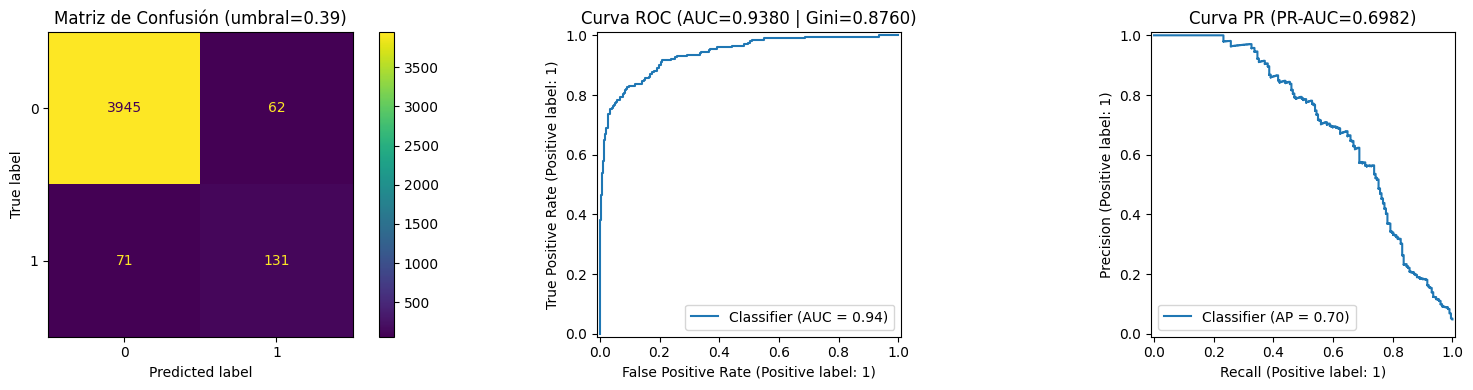

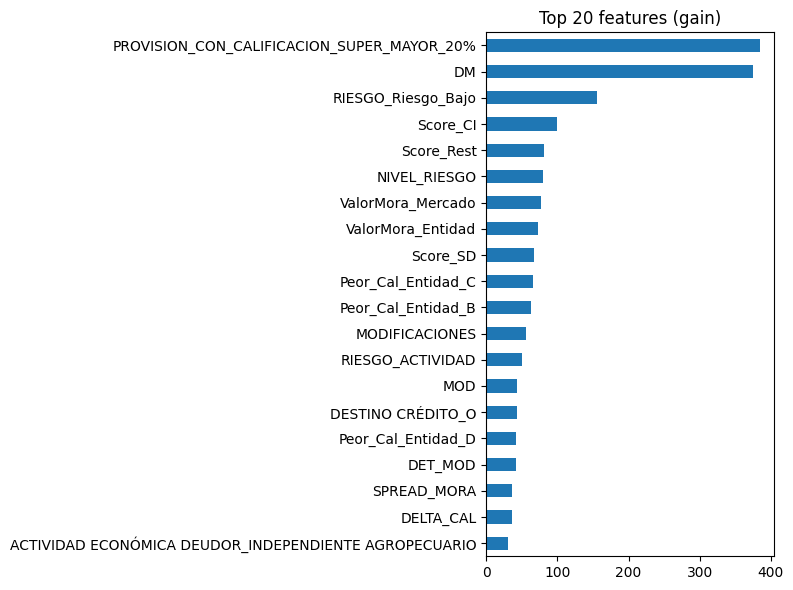

In [164]:
# ── PREPARACIÓN ──────────────────────────────────────────────────────────────
X = df_model.copy()
y = df['empeoro']

# Alinear índices — elimina filas donde y es NaN
mask = y.notna()
X, y = X.loc[mask], y.loc[mask]
y = y.astype(int)

# ── 1. SPLIT ─────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# ── 2. IMPUTACIÓN ────────────────────────────────────────────────────────────
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)
median_train = X_train.median(numeric_only=True)
X_train = X_train.fillna(median_train).fillna(0)
X_test  = X_test.fillna(median_train).fillna(0)

assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum()  == 0

# ── 3. VALIDACIÓN PARA EARLY STOPPING ────────────────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# ── 4. SMOTE ─────────────────────────────────────────────────────────────────
smote = SMOTE(sampling_strategy=0.15, random_state=42, k_neighbors=5)
X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

print("Distribución tras SMOTE:")
print(pd.Series(y_tr_res).value_counts(normalize=True).round(3))

# ── 5. MODELO ────────────────────────────────────────────────────────────────
model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,       # más lento, más estable
    subsample=0.8,
    colsample_bytree=0.7,     # más restricción → menos overfitting
    min_child_weight=10,      # más conservador con clases pequeñas
    gamma=1,                  # poda de nodos: evita splits poco informativos
    reg_alpha=0.1,            # L1: elimina features irrelevantes
    reg_lambda=1.5,           # L2: suaviza pesos
    eval_metric='aucpr',
    early_stopping_rounds=40,
    n_jobs=-1,
    random_state=42
)

model.fit(X_tr_res, y_tr_res, eval_set=[(X_val, y_val)], verbose=50)
print(f"\nMejor iteración: {model.best_iteration}")

# ── 6. EVALUACIÓN ────────────────────────────────────────────────────────────
y_prob = model.predict_proba(X_test)[:, 1]

# Umbral por F1
thresholds = np.arange(0.1, 0.9, 0.01)
f1s = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1s)]
y_pred = (y_prob >= best_thresh).astype(int)

auc  = roc_auc_score(y_test, y_prob)
prauc = average_precision_score(y_test, y_prob)

print(f"\nUmbral óptimo (F1): {best_thresh:.2f}")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC : {auc:.4f}")
print(f"Gini    : {2*auc - 1:.4f}")   # métrica regulatoria estándar
print(f"PR-AUC  : {prauc:.4f}")

# ── 7. GRÁFICAS ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
axes[0].set_title(f'Matriz de Confusión (umbral={best_thresh:.2f})')
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title(f'Curva ROC (AUC={auc:.4f} | Gini={2*auc-1:.4f})')
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2])
axes[2].set_title(f'Curva PR (PR-AUC={prauc:.4f})')
plt.tight_layout()
plt.show()

# ── 8. FEATURE IMPORTANCE (por ganancia) ─────────────────────────────────────
feat_imp = pd.Series(
    model.get_booster().get_score(importance_type='gain'),
    name='gain'
).sort_values(ascending=True).tail(20)

feat_imp.plot(kind='barh', figsize=(8, 6), title='Top 20 features (gain)')
plt.tight_layout()
plt.show()

In [165]:
import joblib
import os

# --- GUARDAR modelo y artefactos necesarios para reproducir el pipeline ---
MODEL_DIR = r'C:\Users\Usuario\OneDrive - Global Green Growth Institute\Documentos\Gadiel\Aplicacion\OneDrive_1_21-3-2026\nuevos'

joblib.dump(model,               os.path.join(MODEL_DIR, 'xgb_empeoro.pkl'))
joblib.dump(median_train,        os.path.join(MODEL_DIR, 'median_train.pkl'))
joblib.dump(X.columns.tolist(),  os.path.join(MODEL_DIR, 'feature_cols.pkl'))

print("Modelos guardados en:", MODEL_DIR)

Modelos guardados en: C:\Users\Usuario\OneDrive - Global Green Growth Institute\Documentos\Gadiel\Aplicacion\OneDrive_1_21-3-2026\nuevos


In [166]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# ── 1. FILTRAR CRÉDITOS QUE EMPEORARON ───────────────────────────────────────
df_emp = df[df['empeoro'] == 1].copy()
print(f"Créditos que empeoraron: {len(df_emp):,}")
print(f"\nCalificación inicial (calif_x_num):\n{df_emp['calif_x_num'].value_counts().sort_index()}")
print(f"\nCalificación final   (calif_y_num):\n{df_emp['calif_y_num'].value_counts().sort_index()}")
print(f"\nTransiciones (inicial → final):\n{pd.crosstab(df_emp['calif_x_num'], df_emp['calif_y_num'])}")

Créditos que empeoraron: 2,023

Calificación inicial (calif_x_num):
calif_x_num
1    1128
2     280
3     237
4     378
Name: count, dtype: int64

Calificación final   (calif_y_num):
calif_y_num
2    439
3    314
4    456
5    814
Name: count, dtype: int64

Transiciones (inicial → final):
calif_y_num    2    3    4    5
calif_x_num                    
1            439  260  296  133
2              0   54   91  135
3              0    0   69  168
4              0    0    0  378


In [167]:
df_emp.columns.to_list()

['VIGENCIA',
 'MES',
 'DÍA',
 'CTVO',
 'TIPO IDENTIFICACIÓN',
 'IDETIFICACIÓN',
 'CÓDIGO CONTABLE',
 'MODIFICACIONES AL CRÉDITO',
 'CRÉDITO',
 'CODCUE',
 'FECHA DESEMBOLSO',
 'FECHA VENCIMIENTO',
 'MOROSIDAD',
 'TIPO CUOTA',
 'CUOTAS PAGADAS',
 'AMORTIZACIÓN',
 'MODALIDAD',
 'TASA INTERÉS NOMINAL',
 'TASA INTERÉS EFECTIVA',
 'VALOR PRÉSTAMO',
 'VALOR CUOTA',
 'SALDO CAPITAL',
 'SALDO INTERESES',
 'OTROS SALDOS',
 'GARANTÍA',
 'FECHA AVALÚO',
 'DETERIORO',
 'DETERIORO INTERESES',
 'CONTINGENCIA',
 'VALOR CUOTA EXTRA',
 'MESES CUOTA EXTRA',
 'FECHA ÚLTIMO PAGO',
 'CLASE GARANTÍA',
 'DESTINO CRÉDITO',
 'CÓDIGO OFICINA',
 'PERIODICIDAD AMORTIZACIÓN',
 'VALOR MORA',
 'TIPO VIVIENDA',
 'SEÑAL VIS ',
 'TIPO O RANGO VIVIENDA',
 'SEÑAL SUBSIDIO',
 'ENTIDAD REDESCUENTO',
 'MARGEN REDESCUENTO',
 'DESEMBOLSO',
 'MONEDA',
 'FECHA MODIFICACIÓN',
 'CALIFICACIÓN ANTES MODIFICACIÓN',
 'VALOR APORTES SOCIALES',
 'VALOR LÍNEA CRÉDITO',
 'MODIFICACIONES',
 'ESTADO CRÉDITO',
 'NIT DEUDOR PATRONAL',
 'NOMBR

Créditos que empeoraron: 2,023

Transiciones reales:
calif_y_num    2    3    4    5
calif_x_num                    
1            439  260  296  133
2              0   54   91  135
3              0    0   69  168
4              0    0    0  378

Clases finales tras agrupación: [2 3 5]
calif_y_agrupada
2    439
3    770
5    814
Name: count, dtype: int64
[0]	validation_0-mlogloss:1.08203
[50]	validation_0-mlogloss:0.72901
[100]	validation_0-mlogloss:0.64336
[150]	validation_0-mlogloss:0.61415
[200]	validation_0-mlogloss:0.60255
[250]	validation_0-mlogloss:0.59838
[300]	validation_0-mlogloss:0.59288
[339]	validation_0-mlogloss:0.59501

Mejor iteración: 299

Clasificación por calificación final:
              precision    recall  f1-score   support

           B       0.45      0.64      0.53        66
         C-D       0.63      0.53      0.58       116
           E       0.92      0.84      0.88       122

    accuracy                           0.68       304
   macro avg       0.67   

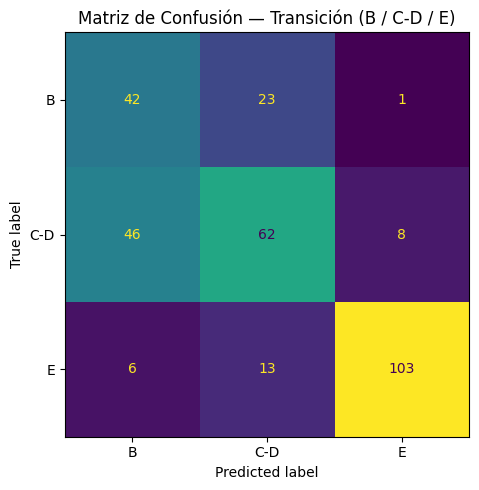


Muestra de predicciones:
         P(B)    P(C-D)      P(E)  calif_inicial  calif_final_real  \
5    0.001683  0.039539  0.958778              3                 5   
15   0.396744  0.585437  0.017818              1                 3   
68   0.018835  0.769043  0.212123              2                 4   
227  0.794324  0.182713  0.022963              1                 2   
249  0.016790  0.839301  0.143909              2                 4   
274  0.458834  0.510233  0.030934              1                 4   
352  0.001114  0.007970  0.990915              4                 5   
358  0.008226  0.024523  0.967251              4                 5   
430  0.304361  0.688068  0.007571              1                 4   
628  0.039469  0.731664  0.228867              2                 3   

     calif_pred calif_pred_label  
5             5                E  
15            3              C-D  
68            3              C-D  
227           2                B  
249           3             

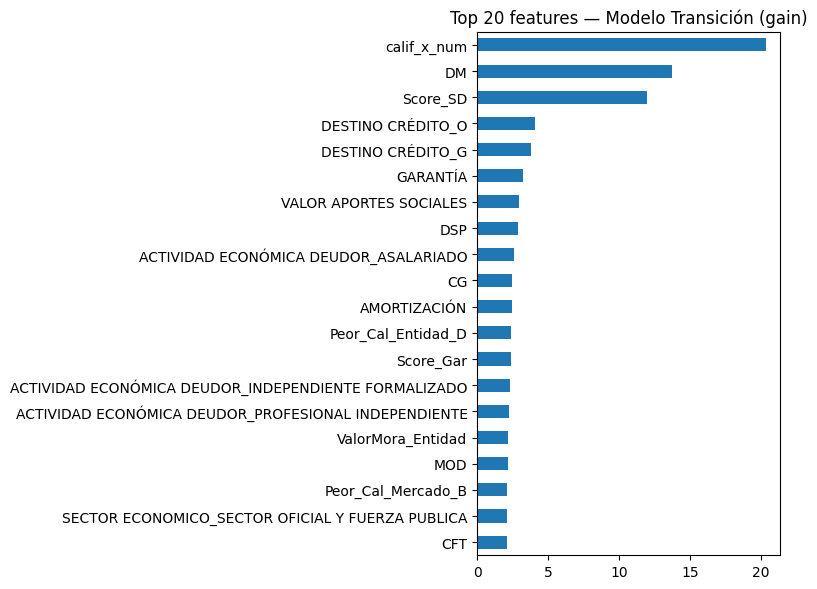

Modelos de transición guardados.


In [169]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt

# ── 1. FILTRAR EMPEORARON ─────────────────────────────────────────────────────
df_emp = df[df['empeoro'] == 1].copy()
print(f"Créditos que empeoraron: {len(df_emp):,}")
print(f"\nTransiciones reales:\n{pd.crosstab(df_emp['calif_x_num'], df_emp['calif_y_num'])}")

# ── 2. TARGET: FUSIONAR C(3) y D(4) → categoría 3 ───────────────────────────
# Justificación regulatoria: C y D comparten tratamiento de cartera en riesgo;
# la distinción fina entre ambas no altera el cálculo de provisiones de forma
# significativa. La categoría E (incobrable) se mantiene separada por su
# tratamiento contable diferenciado.
df_emp['calif_y_agrupada'] = df_emp['calif_y_num'].replace({4: 3})

y_trans = df_emp['calif_y_agrupada'].astype(int)
le = LabelEncoder()
y_enc = le.fit_transform(y_trans)
print(f"\nClases finales tras agrupación: {le.classes_}")
print(pd.Series(y_trans).value_counts().sort_index())

# ── 3. FEATURES ───────────────────────────────────────────────────────────────
num_cols_trans = [
    'calif_x_num',                              # calificación de partida
    'Score_CP', 'Score_Sol', 'Score_Gar',       # scores CBCF
    'Score_SD', 'Score_Rest', 'Score_CI', 'Score_PE',
    'RCI', 'CFT', 'NET', 'VI', 'RS', 'CA', 'CG',
    'DM', 'DSP', 'DELTA_CAL', 'SPREAD_MORA',
    'RIESGO_SECTOR', 'RIESGO_ACTIVIDAD',
    'FLAG_ARRASTRE', 'NIVEL_RIESGO',
    'MOD', 'MOD_CE',
    'CUOTAS PAGADAS', 'AMORTIZACIÓN', 'MODIFICACIONES',
    'TASA INTERÉS NOMINAL', 'TASA INTERÉS EFECTIVA',
    'VALOR PRÉSTAMO', 'VALOR CUOTA', 'SALDO CAPITAL', 'SALDO INTERESES',
    'GARANTÍA', 'VALOR APORTES SOCIALES',
    'INGRESOS ACTUALES', 'INGRESOS AÑO ANTERIOR',
    'ACTIVOS', 'PASIVOS',
    'ValorMora_Entidad', 'ValorMora_Mercado',
    'PROVISION_CON_CALIFICACION_SUPER_MAYOR_20%',
]

cat_cols_trans = [
    'TIPO CUOTA', 'MODALIDAD', 'PERIODICIDAD AMORTIZACIÓN',
    'DESTINO CRÉDITO', 'CLASE GARANTÍA',
    'ACTIVIDAD ECONÓMICA DEUDOR', 'SECTOR ECONOMICO',
    'Peor_Cal_Entidad', 'Peor_Cal_Mercado',
    'RIESGO',
]

X_trans = pd.concat([
    df_emp[num_cols_trans],
    pd.get_dummies(df_emp[cat_cols_trans], drop_first=True)
], axis=1).apply(pd.to_numeric, errors='coerce')

# ── 4. SPLIT + IMPUTACIÓN ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_trans, y_enc, test_size=0.15, random_state=42, stratify=y_enc
)

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)
median_trans = X_train.median(numeric_only=True)
X_train = X_train.fillna(median_trans).fillna(0)
X_test  = X_test.fillna(median_trans).fillna(0)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# ── 5. PESOS POR CLASE (compensa desbalance sin SMOTE) ───────────────────────
sample_w = compute_sample_weight('balanced', y_tr)

# ── 6. MODELO MULTICLASE ──────────────────────────────────────────────────────
n_clases = len(le.classes_)

model_trans = XGBClassifier(
    objective='multi:softprob',
    num_class=n_clases,
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=3,       # más bajo para clases pequeñas
    reg_alpha=0.1,
    reg_lambda=1.5,
    eval_metric='mlogloss',
    early_stopping_rounds=40,
    n_jobs=-1,
    random_state=42
)

model_trans.fit(
    X_tr, y_tr,
    sample_weight=sample_w,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"\nMejor iteración: {model_trans.best_iteration}")

# ── 7. EVALUACIÓN ─────────────────────────────────────────────────────────────
y_pred_enc = model_trans.predict(X_test)
y_pred_cal = le.inverse_transform(y_pred_enc)
y_test_cal = le.inverse_transform(y_test)

etiquetas = {2: 'B', 3: 'C-D', 5: 'E'}
labels_display = [etiquetas.get(c, str(c)) for c in le.classes_]

print("\nClasificación por calificación final:")
print(classification_report(y_test_cal, y_pred_cal,
      target_names=labels_display))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_cal, y_pred_cal,
    display_labels=labels_display,
    ax=ax, colorbar=False
)
ax.set_title('Matriz de Confusión — Transición (B / C-D / E)')
plt.tight_layout()
plt.show()

# ── 8. PROBABILIDADES POR CLASE SOBRE TODOS LOS QUE EMPEORARON ───────────────
X_full = X_trans.fillna(median_trans).fillna(0)
prob_trans = model_trans.predict_proba(X_full)

prob_df = pd.DataFrame(
    prob_trans,
    columns=[f'P({etiquetas.get(c,c)})' for c in le.classes_],
    index=df_emp.index
)
prob_df['calif_inicial']    = df_emp['calif_x_num'].values
prob_df['calif_final_real'] = df_emp['calif_y_num'].values
prob_df['calif_pred']       = le.inverse_transform(model_trans.predict(X_full))
prob_df['calif_pred_label'] = prob_df['calif_pred'].map(etiquetas)

print("\nMuestra de predicciones:")
print(prob_df.head(10))

# ── 9. FEATURE IMPORTANCE ─────────────────────────────────────────────────────
feat_imp = pd.Series(
    model_trans.get_booster().get_score(importance_type='gain')
).sort_values(ascending=True).tail(20)

feat_imp.plot(kind='barh', figsize=(8, 6),
              title='Top 20 features — Modelo Transición (gain)')
plt.tight_layout()
plt.show()

# ── 10. GUARDAR ───────────────────────────────────────────────────────────────
joblib.dump(model_trans,              os.path.join(MODEL_DIR, 'xgb_transicion.pkl'))
joblib.dump(median_trans,             os.path.join(MODEL_DIR, 'median_trans.pkl'))
joblib.dump(le,                       os.path.join(MODEL_DIR, 'label_encoder_trans.pkl'))
joblib.dump(X_trans.columns.tolist(), os.path.join(MODEL_DIR, 'feature_cols_trans.pkl'))
print("Modelos de transición guardados.")


In [172]:
# ── GUARDAR MODELO DE TRANSICIÓN ─────────────────────────────────────────────
import joblib, os

MODEL_DIR = r'C:\Users\Usuario\OneDrive - Global Green Growth Institute\Documentos\Gadiel\Aplicacion\OneDrive_1_21-3-2026\nuevos'

joblib.dump(model_trans,              os.path.join(MODEL_DIR, 'xgb_transicion.pkl'))
joblib.dump(median_trans,             os.path.join(MODEL_DIR, 'median_trans.pkl'))
joblib.dump(le,                       os.path.join(MODEL_DIR, 'label_encoder_trans.pkl'))
joblib.dump(X_trans.columns.tolist(), os.path.join(MODEL_DIR, 'feature_cols_trans.pkl'))

print("Modelos guardados en:", MODEL_DIR)


Modelos guardados en: C:\Users\Usuario\OneDrive - Global Green Growth Institute\Documentos\Gadiel\Aplicacion\OneDrive_1_21-3-2026\nuevos


# Pronostico

In [106]:
import joblib
import os

# --- GUARDAR modelo y artefactos necesarios para reproducir el pipeline ---
MODEL_DIR = r'C:\Users\Usuario\OneDrive - Global Green Growth Institute\Documentos\Gadiel\Aplicacion\OneDrive_1_21-3-2026\nuevos'

joblib.dump(model,        os.path.join(MODEL_DIR, 'xgb_empeoro.pkl'))
joblib.dump(median_train, os.path.join(MODEL_DIR, 'median_train.pkl'))
joblib.dump(X.columns.tolist(), os.path.join(MODEL_DIR, 'feature_cols.pkl'))

print("Modelo y artefactos guardados.")


Modelo y artefactos guardados.


In [173]:
# --- CARGAR y predecir sobre nuevo periodo ---
import joblib, os, pandas as pd, numpy as np

MODEL_DIR = r'C:\Users\Usuario\OneDrive - Global Green Growth Institute\Documentos\Gadiel\Aplicacion\OneDrive_1_21-3-2026\nuevos'

model        = joblib.load(os.path.join(MODEL_DIR, 'xgb_empeoro.pkl'))
median_train = joblib.load(os.path.join(MODEL_DIR, 'median_train.pkl'))
feature_cols = joblib.load(os.path.join(MODEL_DIR, 'feature_cols.pkl'))

# ── Cargar datos del nuevo periodo ───────────────────────────────────────────
cartera_nuevo  = pd.read_excel(os.path.join(MODEL_DIR, 'Informe_Cartera_ENERO2026.xlsx'), header=0)
df_calif_nuevo = pd.read_excel(
    os.path.join(MODEL_DIR, 'CalCartera_Analisis_UTRAHUILCA DIC2025.xlsx'),
    sheet_name='Analisis_Cal_Cartera'
)

cartera_nuevo["IDETIFICACIÓN"] = cartera_nuevo["IDETIFICACIÓN"].astype(str)
df_calif_nuevo["NUMERO_ID"]    = df_calif_nuevo["NUMERO_ID"].astype(str)
df_calif_nuevo = df_calif_nuevo.drop_duplicates(subset="NUMERO_ID")

df = cartera_nuevo.merge(
    df_calif_nuevo[[
        "NUMERO_ID",
        "CALIF_DE_ARRASTRE_SUPER_MAYOR_20%",
        "PROVISION_CON_CALIFICACION_SUPER_MAYOR_20%",
        "RANGO PARTICIPACIÓN ENTIDAD EN ENDEUDAMIENTO GLOBAL DEL CLIENTE",
        "AlturaMora_Entidad", "AlturaMora_Mercado",
        "ValorMora_Entidad",  "ValorMora_Mercado",
        "Peor_Cal_Entidad",   "Peor_Cal_Mercado",
        "INSOLVENCIA", "RIESGO"
    ]],
    left_on="IDETIFICACIÓN", right_on="NUMERO_ID", how="left"
)

print(f"Registros cargados: {df.shape[0]:,}")

# ── Fecha de corte ───────────────────────────────────────────────────────────
fecha_corte = pd.to_datetime(df[['VIGENCIA','MES','DÍA']].rename(
    columns={'VIGENCIA':'year','MES':'month','DÍA':'day'}))

# ════════════════════════════════════════════════════════════════════════════
# CONSTRUCCIÓN DE FEATURES (mismo pipeline que entrenamiento)
# ════════════════════════════════════════════════════════════════════════════

# ── 1. CAPACIDAD DE PAGO ─────────────────────────────────────────────────────
df['RCI'] = np.where(df['INGRESOS ACTUALES'] > 0,
    df['VALOR CUOTA'] / df['INGRESOS ACTUALES'], np.nan)
df['CFT'] = np.where(df['INGRESOS ACTUALES'] > 0,
    (df['VALOR CUOTA'] + df['SALDO INTERESES']) / df['INGRESOS ACTUALES'], np.nan)
df['VI']  = np.where(df['INGRESOS AÑO ANTERIOR'] > 0,
    (df['INGRESOS ACTUALES'] - df['INGRESOS AÑO ANTERIOR']) / df['INGRESOS AÑO ANTERIOR'], np.nan)
df['NET'] = np.where(df['ACTIVOS'] > 0, df['PASIVOS'] / df['ACTIVOS'], np.nan)

for col in ['RCI','CFT','VI','NET']:
    df[col] = df[col].clip(upper=df[col].quantile(0.99))

df['Score_CP'] = (
    (df['RCI']  > 0.30).astype(int) +
    (df['CFT']  > 0.40).astype(int) +
    (df['NET']  > 0.70).astype(int) +
    (df['VI']   < 0.00).astype(int)
)

# ── 2. SOLVENCIA ─────────────────────────────────────────────────────────────
df['RS'] = np.where(df['PASIVOS'] > 0, df['ACTIVOS'] / df['PASIVOS'], np.nan)
deuda_entidad = df['SALDO CAPITAL'] + df['SALDO INTERESES'] + df['OTROS SALDOS']
df['CA'] = np.where(deuda_entidad > 0, df['ACTIVOS'] / deuda_entidad, np.nan)

for col in ['RS','CA']:
    df[col] = df[col].clip(upper=df[col].quantile(0.99))

df['INSOLVENCIA'] = pd.to_numeric(df['INSOLVENCIA'], errors='coerce').fillna(0).astype(int)

df['Score_Sol'] = (
    (df['RS'] < 1.0).astype(int) +
    (df['CA'] < 1.0).astype(int) +
    (df['INSOLVENCIA'] == 1).astype(int)
)

# ── 3. GARANTÍAS ─────────────────────────────────────────────────────────────
df['CG'] = np.where(df['SALDO CAPITAL'] > 0,
    df['GARANTÍA'] / df['SALDO CAPITAL'], np.nan)
df['CG'] = df['CG'].clip(upper=df['CG'].quantile(0.99))

admisibles = [
    '1-HIPOTECA', '5-PRENDARIA', '6-CERTIFICADO GARANTIAS(FRGT)',
    '2-APORTES SOCIALES', '11-FAG', '16-FONDO DE GARANTIAS(FAG ESPECIA',
    '17-FNG (Unidos por el cambio EMP3', '14-PIGNORACION DE CONTRATOS',
    '12-CESION DE DERECHOS'
]
df['GA'] = np.where(
    df['DETALLE GARANTÍA'].astype(str).str.strip().isin(admisibles), 1, 0)

df['FECHA AVALÚO'] = pd.to_datetime(df['FECHA AVALÚO'], errors='coerce')
df['AA'] = ((fecha_corte - df['FECHA AVALÚO']).dt.days / 30).clip(lower=0)
df['AA'] = df['AA'].clip(upper=df['AA'].quantile(0.99))

penaliza_CG = ((df['GA'] == 1) & (df['CG'] < 1.0)).astype(int)
penaliza_AA = ((df['GA'] == 1) & (df['AA'] > 48)).astype(int)
df['Score_Gar'] = (df['GA'] == 0).astype(int) + penaliza_CG + penaliza_AA

# ── 4. SERVICIO DE LA DEUDA ──────────────────────────────────────────────────
df['DM'] = pd.to_numeric(df['AlturaMora_Entidad'], errors='coerce') \
             .fillna(pd.to_numeric(df['MOROSIDAD'], errors='coerce')).clip(lower=0)

df['FECHA ÚLTIMO PAGO'] = pd.to_datetime(df['FECHA ÚLTIMO PAGO'], errors='coerce')
df['DSP'] = ((fecha_corte - df['FECHA ÚLTIMO PAGO']).dt.days).clip(lower=0)
df['DSP'] = df['DSP'].clip(upper=df['DSP'].quantile(0.99))

df['Score_SD'] = (
    (df['DM']  > 30).astype(int) +
    (df['DM']  > 90).astype(int) +
    (df['DSP'] > 60).astype(int)
)

# ── 5. REESTRUCTURACIONES ────────────────────────────────────────────────────
df['MOD']     = (pd.to_numeric(df['MODIFICACIONES'], errors='coerce').fillna(0) > 0).astype(int)
df['MOD_CE']  = (
    (df['MODIFICACIONES DEL CRÉDITO CE 11/20'].astype(str).str.strip().isin(['0','nan']) == False) |
    (df['MODIFICACIONES AL CRÉDITO CE 17/20'].astype(str).str.strip().isin(['0','nan']) == False)
).astype(int)
df['DET_MOD'] = 0   # sin target en producción; se mantiene en 0

df['Score_Rest'] = df['MOD'] + df['MOD_CE'] + df['DET_MOD']

# ── 6. CENTRALES DE INFORMACIÓN ──────────────────────────────────────────────
cal_map = {'A':1,'B':2,'C':3,'D':4,'E':5}
df['Peor_Cal_Mercado_n'] = df['Peor_Cal_Mercado'].map(cal_map)
df['Peor_Cal_Entidad_n'] = df['Peor_Cal_Entidad'].map(cal_map)
df['DELTA_CAL']  = (df['Peor_Cal_Mercado_n'] - df['Peor_Cal_Entidad_n']).fillna(0)

df['ValorMora_Mercado'] = pd.to_numeric(df['ValorMora_Mercado'], errors='coerce').fillna(0)
df['ValorMora_Entidad'] = pd.to_numeric(df['ValorMora_Entidad'], errors='coerce').fillna(0)
df['SPREAD_MORA'] = (df['ValorMora_Mercado'] - df['ValorMora_Entidad']).clip(lower=0)
df['SPREAD_MORA'] = df['SPREAD_MORA'].clip(upper=df['SPREAD_MORA'].quantile(0.99))

df['FLAG_ARRASTRE'] = pd.to_numeric(
    df['CALIF_DE_ARRASTRE_SUPER_MAYOR_20%'], errors='coerce').fillna(0).clip(0,1).astype(int)

riesgo_map = {'Riesgo_Bajo':0,'Riesgo_Medio':1,'Riesgo_Alto':2,'Riesgo_Muy_Alto':3}
df['NIVEL_RIESGO'] = df['RIESGO'].map(riesgo_map).fillna(1)

df['Score_CI'] = (
    (df['DELTA_CAL']      > 0).astype(int) +
    (df['SPREAD_MORA']    > 0).astype(int) +
    (df['FLAG_ARRASTRE'] == 1).astype(int) +
    (df['INSOLVENCIA']   == 1).astype(int) +
    (df['NIVEL_RIESGO']   > 1).astype(int)
)

# ── 7. PERSPECTIVAS ECONÓMICAS ───────────────────────────────────────────────
riesgo_sector = {
    'JUBILADOS PENSIONADOS':0, 'EDUCACION':0,
    'SECTOR OFICIAL Y FUERZA PUBLICA':0, 'SALUD':0,
    'INTERMEDIACION FINANCIERA':1, 'SERVICIOS Y OTRAS ACTIVIDADES':1,
    'CONSUMO (COMERCIO)':1, 'MANUFACTURA':1,
    'INMOBILIARIAS Y DE ALQUILER':1, 'SECTOR ECONOMIA SOLIDARIA (NO FINANCIERO)':1,
    'AGRICOLA':2, 'PECUARIO':2, 'TRANSPORTE':2,
    'CONSTRUCCION Y VIVIENDA':2, 'HOTELES, RESTAURANTES, BARES Y SIMILARES':2,
    'MINERO Y ENERGETICO':3,
}
riesgo_actividad = {
    'JUBILADO PENSIONADO':0, 'ASALARIADO':0, 'DEPENDIENTE':0,
    'PROFESIONAL INDEPENDIENTE':1, 'INDEPENDIENTE FORMALIZADO':1, 'PERSONA JURIDICA':1,
    'INDEPENDIENTE AGROPECUARIO':2, 'INDEPENDIENTE INFORMAL':2, 'EMPLEADA DOMESTICA':2,
}
df['RIESGO_SECTOR']   = df['SECTOR ECONOMICO'].map(riesgo_sector).fillna(1)
df['RIESGO_ACTIVIDAD']= df['ACTIVIDAD ECONÓMICA DEUDOR'].map(riesgo_actividad).fillna(1)

df['Score_PE'] = (
    (df['RIESGO_SECTOR']    >= 2).astype(int) +
    (df['RIESGO_SECTOR']    == 3).astype(int) +
    (df['RIESGO_ACTIVIDAD'] >= 2).astype(int)
)

# ════════════════════════════════════════════════════════════════════════════
# ARMADO DE X_NUEVO Y PREDICCIÓN
# ════════════════════════════════════════════════════════════════════════════
num_cols = [
    'CUOTAS PAGADAS', 'AMORTIZACIÓN', 'MODIFICACIONES',
    'TASA INTERÉS NOMINAL', 'TASA INTERÉS EFECTIVA',
    'VALOR PRÉSTAMO', 'VALOR CUOTA', 'SALDO CAPITAL', 'SALDO INTERESES',
    'GARANTÍA', 'CONTINGENCIA', 'VALOR APORTES SOCIALES',
    'INGRESOS ACTUALES', 'INGRESOS AÑO ANTERIOR', 'ACTIVOS', 'PASIVOS',
    'PROVISION_CON_CALIFICACION_SUPER_MAYOR_20%',
    'ValorMora_Entidad', 'ValorMora_Mercado',
    'Score_CP', 'Score_Sol', 'Score_Gar', 'Score_SD',
    'Score_Rest', 'Score_CI', 'Score_PE',
    'RCI', 'CFT', 'NET', 'VI', 'RS', 'CA', 'CG',
    'DM', 'DSP', 'DELTA_CAL', 'SPREAD_MORA',
    'RIESGO_SECTOR', 'RIESGO_ACTIVIDAD',
    'FLAG_ARRASTRE', 'NIVEL_RIESGO', 'MOD', 'MOD_CE', 'DET_MOD',
]
cat_cols = [
    'TIPO CUOTA', 'MODALIDAD', 'PERIODICIDAD AMORTIZACIÓN',
    'DESTINO CRÉDITO', 'TIPO VIVIENDA', 'CLASE GARANTÍA',
    'ACTIVIDAD ECONÓMICA DEUDOR', 'SECTOR ECONOMICO',
    'Peor_Cal_Entidad', 'Peor_Cal_Mercado',
    'AlturaMora_Entidad', 'AlturaMora_Mercado',
    'INSOLVENCIA', 'RIESGO',
    'RANGO PARTICIPACIÓN ENTIDAD EN ENDEUDAMIENTO GLOBAL DEL CLIENTE',
]

X_nuevo = pd.concat([
    df[num_cols],
    pd.get_dummies(df[cat_cols], drop_first=True)
], axis=1)

# Alinear columnas exactas del entrenamiento
X_nuevo = X_nuevo.reindex(columns=feature_cols, fill_value=0)

# Imputación con mediana del entrenamiento
X_nuevo = X_nuevo.replace([np.inf, -np.inf], np.nan)
X_nuevo = X_nuevo.fillna(median_train).fillna(0)

# ── Pronóstico ───────────────────────────────────────────────────────────────
best_thresh = 0.35

df['prob_empeoro'] = model.predict_proba(X_nuevo)[:, 1]
df['pred_empeoro'] = (df['prob_empeoro'] >= best_thresh).astype(int)

print(f"Créditos en riesgo de empeorar: {df['pred_empeoro'].sum():,} de {len(df):,}")
print(df[['CODCUE','IDETIFICACIÓN','prob_empeoro','pred_empeoro']]
      .sort_values('prob_empeoro', ascending=False).head(20))

df.to_excel(os.path.join(MODEL_DIR, 'pronostico_enero2026_II.xlsx'), index=False)
print("Pronóstico exportado.")

Registros cargados: 57,860
Créditos en riesgo de empeorar: 2,256 de 57,860
         CODCUE IDETIFICACIÓN  prob_empeoro  pred_empeoro
18866  11498781    4347173996      0.981397             1
17480  11530077    8158366016      0.981329             1
17825  11506665    6222007472      0.980395             1
20059  11465552     219924504      0.979922             1
21451  11543469    2992159516      0.978619             1
32735  11491074    2100630914      0.974319             1
20759  11508242    1357216664      0.972940             1
18738  11534349    2641649471      0.972556             1
44561  11530506    5007966917      0.969522             1
45101  11529210    3403248107      0.968078             1
21046  11484908    3126895645      0.967201             1
22055  11517391    8570475166      0.966864             1
28648  11549149    7687128817      0.966449             1
20209  11492275    5416815953      0.963300             1
18110  11463529    7626204002      0.963092            

In [182]:
best_thresh = 0.35

df['prob_empeoro'] = model.predict_proba(X_nuevo)[:, 1]
df['pred_empeoro'] = (df['prob_empeoro'] >= best_thresh).astype(int)

print(f"Créditos en riesgo de empeorar: {df['pred_empeoro'].sum():,} de {len(df):,}")

# ── MODELO 2: TRANSICIÓN — solo sobre los que empeorarán ─────────────────────
cal_map_num = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5}
df_nuevos_emp = df[df['pred_empeoro'] == 1].copy()
df_nuevos_emp['calif_x_num'] = df_nuevos_emp['CALIFICACIÓN'].map(cal_map_num).fillna(1)

print(f"Créditos a clasificar en transición: {len(df_nuevos_emp):,}")

X_nuevos_emp = pd.concat([
    df_nuevos_emp[num_cols_trans],
    pd.get_dummies(df_nuevos_emp[cat_cols_trans], drop_first=True)
], axis=1).apply(pd.to_numeric, errors='coerce')

X_nuevos_emp = X_nuevos_emp.reindex(columns=feature_cols_trans, fill_value=0)
X_nuevos_emp = X_nuevos_emp.replace([np.inf, -np.inf], np.nan)
X_nuevos_emp = X_nuevos_emp.fillna(median_trans).fillna(0)

etiquetas = {2: 'B', 3: 'C-D', 5: 'E'}

prob_nuevos = model_trans.predict_proba(X_nuevos_emp)
pred_nuevos = model_trans.predict(X_nuevos_emp)

prob_resultado = pd.DataFrame(
    prob_nuevos,
    columns=[f'P({etiquetas.get(c,c)})' for c in le.classes_],
    index=df_nuevos_emp.index
)
prob_resultado['calif_pred_num']   = le.inverse_transform(pred_nuevos)
prob_resultado['calif_pred_label'] = prob_resultado['calif_pred_num'].map(etiquetas)

df = df.join(prob_resultado, how='left')

print(f"\nDistribución calificación predicha (empeoraron):")
print(df['calif_pred_label'].value_counts())
print(df[['CODCUE','IDETIFICACIÓN','prob_empeoro','pred_empeoro',
          'calif_pred_label','P(B)','P(C-D)','P(E)']]
      .sort_values('prob_empeoro', ascending=False).head(20))

df.to_excel(os.path.join(MODEL_DIR, 'pronostico_enero2026.xlsx'), index=False)
print("\nExportado.")


Créditos en riesgo de empeorar: 2,256 de 57,860
Créditos a clasificar en transición: 2,256

Distribución calificación predicha (empeoraron):
calif_pred_label
E      947
B      691
C-D    618
Name: count, dtype: int64
         CODCUE IDETIFICACIÓN  prob_empeoro  pred_empeoro calif_pred_label  \
18866  11498781    4347173996      0.981397             1                E   
17480  11530077    8158366016      0.981329             1                E   
17825  11506665    6222007472      0.980395             1                E   
20059  11465552     219924504      0.979922             1                E   
21451  11543469    2992159516      0.978619             1                E   
32735  11491074    2100630914      0.974319             1                E   
20759  11508242    1357216664      0.972940             1                E   
18738  11534349    2641649471      0.972556             1                E   
44561  11530506    5007966917      0.969522             1                E   
451

In [188]:
df.columns

Index(['VIGENCIA', 'MES', 'DÍA', 'CTVO', 'TIPO IDENTIFICACIÓN',
       'IDETIFICACIÓN', 'CÓDIGO CONTABLE', 'MODIFICACIONES AL CRÉDITO',
       'CRÉDITO', 'CODCUE', 'FECHA DESEMBOLSO', 'FECHA VENCIMIENTO',
       'MOROSIDAD', 'TIPO CUOTA', 'CUOTAS PAGADAS', 'AMORTIZACIÓN',
       'MODALIDAD', 'TASA INTERÉS NOMINAL', 'TASA INTERÉS EFECTIVA',
       'VALOR PRÉSTAMO', 'VALOR CUOTA', 'SALDO CAPITAL', 'SALDO INTERESES',
       'OTROS SALDOS', 'GARANTÍA', 'FECHA AVALÚO', 'DETERIORO',
       'DETERIORO INTERESES', 'CONTINGENCIA', 'VALOR CUOTA EXTRA',
       'MESES CUOTA EXTRA', 'FECHA ÚLTIMO PAGO', 'CLASE GARANTÍA',
       'DESTINO CRÉDITO', 'CÓDIGO OFICINA', 'PERIODICIDAD AMORTIZACIÓN',
       'VALOR MORA', 'TIPO VIVIENDA', 'SEÑAL VIS ', 'TIPO O RANGO VIVIENDA',
       'SEÑAL SUBSIDIO', 'ENTIDAD REDESCUENTO', 'MARGEN REDESCUENTO',
       'DESEMBOLSO', 'MONEDA', 'FECHA MODIFICACIÓN',
       'CALIFICACIÓN ANTES MODIFICACIÓN', 'VALOR APORTES SOCIALES',
       'VALOR LÍNEA CRÉDITO', 'MODIFICACION

In [189]:
# Diccionario que resuelve cada categoría a su mejor calificación
# Para rangos, tomas la menos mala (la primera del rango)
resolucion_rango = {
    "A":   "A",
    "B":   "B",
    "C":   "C",
    "D":   "D",
    "E":   "E",
    "B-C": "B",
    "C-D": "C",
    "D-E": "D"
}

orden_calif = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5}

# Resolver el rango a calificación puntual
df["calif_pred_resuelta"] = df["calif_pred_label"].map(resolucion_rango)

# Mapear a numérico
df["calif_actual_num"]  = df["CALIFICACIÓN"].map(orden_calif)
df["calif_pred_num"]    = df["calif_pred_resuelta"].map(orden_calif)

# Regla del peor
df["calif_final_num"] = df[["calif_actual_num", "calif_pred_num"]].max(axis=1)

# Si no hubo predicción, queda la actual
df["calif_final_num"] = df["calif_final_num"].fillna(df["calif_actual_num"])

# Convertir de vuelta a etiqueta
orden_inv = {v: k for k, v in orden_calif.items()}
df["calif_final"] = df["calif_final_num"].map(orden_inv)

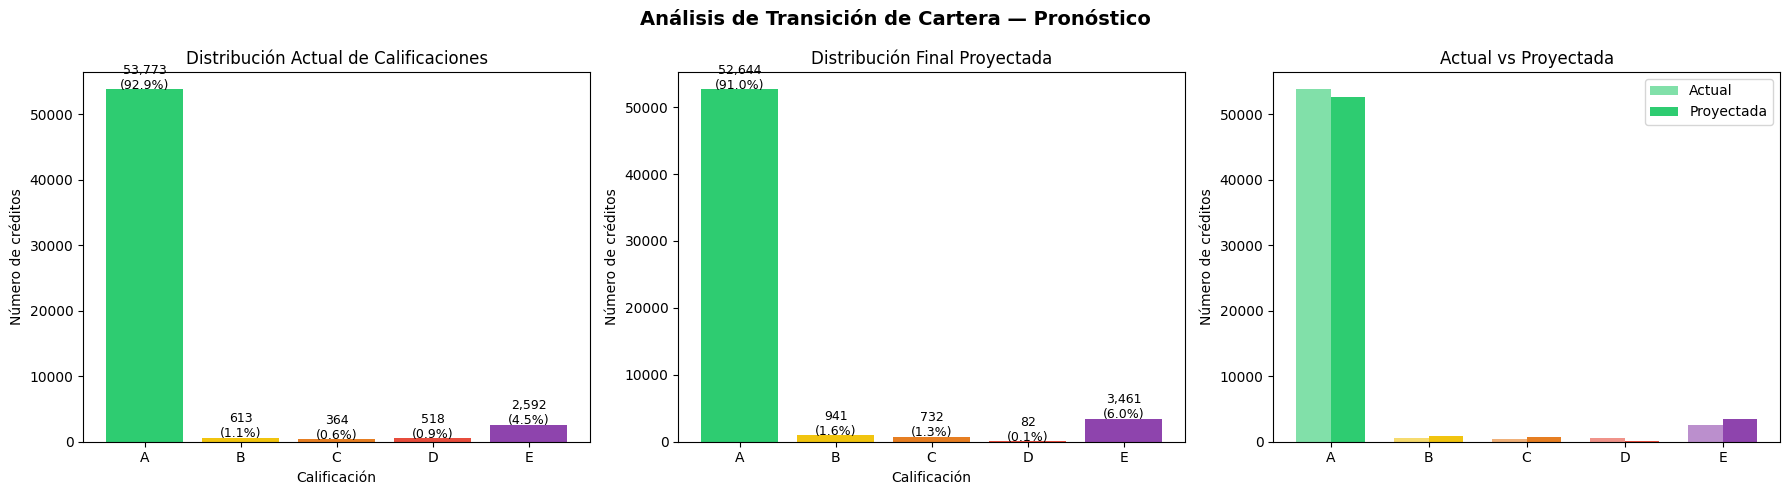


Matriz de Transición — Valores Absolutos (créditos que cambian):
calif_final   A    B    C  D    E  Total
CALIFICACIÓN                            
A             0  691  329  0  109   1129
B             0    0  202  0  161    363
C             0    0    0  0  163    163
D             0    0    0  0  436    436
E             0    0    0  0    0      0
Total         0  691  531  0  869   2091


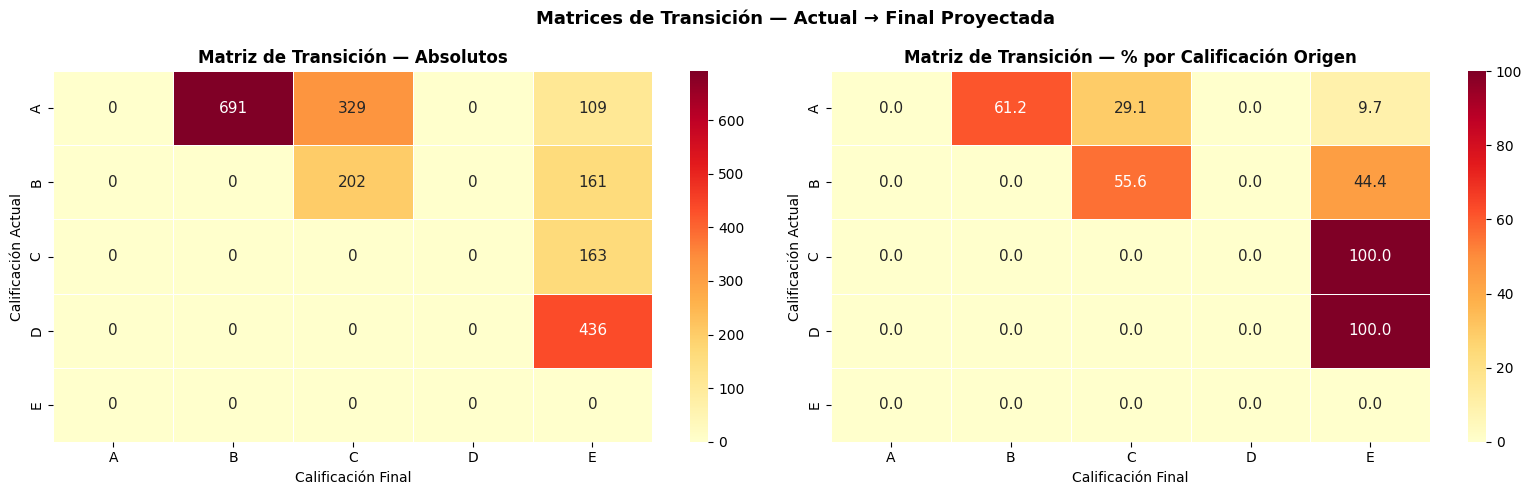

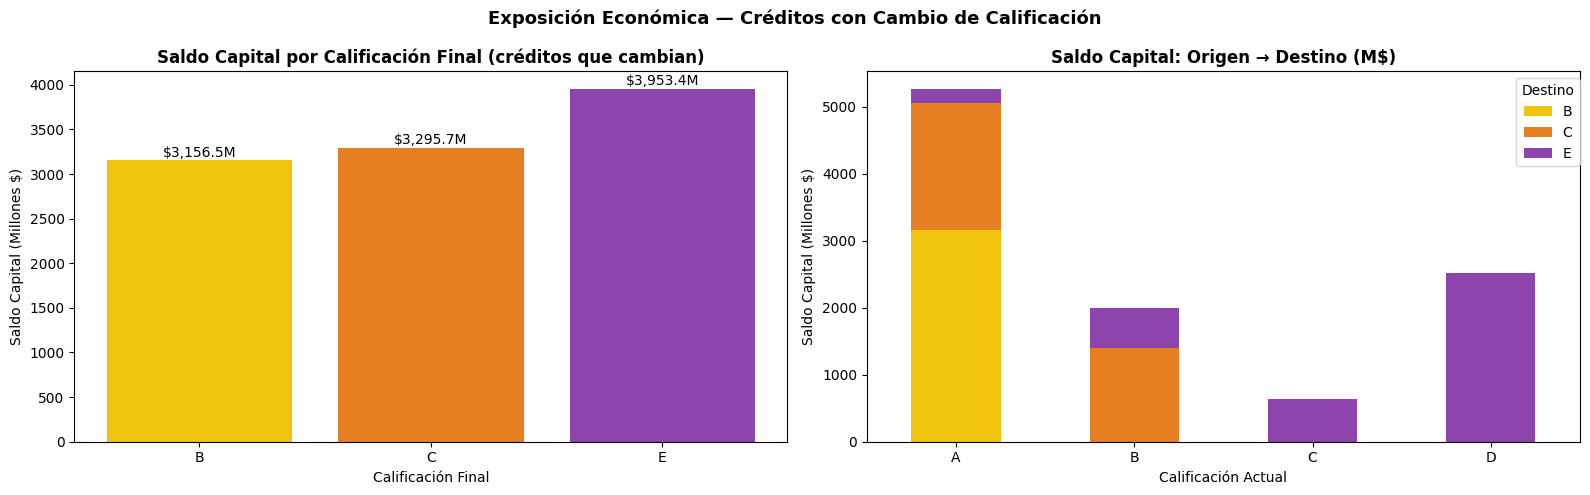


         RESUMEN EJECUTIVO — PRONÓSTICO DE CARTERA
  Total créditos analizados      :     57,860
  Créditos que cambian calif.    :      2,091 (3.6%)
  Saldo total cartera            : $ 536,821.6M
  Saldo con cambio de calif.     : $  10,405.6M (1.9%)
-------------------------------------------------------
  Distribución calificación final (cambian):
    → B   :   691 créditos  |  $3,156.5M
    → C   :   531 créditos  |  $3,295.7M
    → E   :   869 créditos  |  $3,953.4M


In [190]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

orden_cal  = ['A', 'B', 'C', 'D', 'E']
colores_cal = {'A':'#2ecc71','B':'#f1c40f','C':'#e67e22','D':'#e74c3c','E':'#8e44ad'}

# ── 1. DISTRIBUCIÓN ACTUAL vs FINAL ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de Transición de Cartera — Pronóstico', fontsize=14, fontweight='bold')

# Panel 1: calificación actual
cal_actual = df['CALIFICACIÓN'].value_counts().reindex(orden_cal, fill_value=0)
axes[0].bar(cal_actual.index, cal_actual.values,
            color=[colores_cal[k] for k in cal_actual.index])
axes[0].set_title('Distribución Actual de Calificaciones')
axes[0].set_xlabel('Calificación')
axes[0].set_ylabel('Número de créditos')
for i, (k, v) in enumerate(cal_actual.items()):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Panel 2: calificación final proyectada
cal_final = df['calif_final'].value_counts().reindex(orden_cal, fill_value=0)
axes[1].bar(cal_final.index, cal_final.values,
            color=[colores_cal[k] for k in cal_final.index])
axes[1].set_title('Distribución Final Proyectada')
axes[1].set_xlabel('Calificación')
axes[1].set_ylabel('Número de créditos')
for i, (k, v) in enumerate(cal_final.items()):
    axes[1].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Panel 3: comparativo actual vs final (barras agrupadas)
x = np.arange(len(orden_cal))
w = 0.35
bars1 = axes[2].bar(x - w/2, [cal_actual.get(c,0) for c in orden_cal], w,
                    label='Actual', color=[colores_cal[c] for c in orden_cal], alpha=0.6)
bars2 = axes[2].bar(x + w/2, [cal_final.get(c,0) for c in orden_cal],  w,
                    label='Proyectada', color=[colores_cal[c] for c in orden_cal], alpha=1.0)
axes[2].set_xticks(x)
axes[2].set_xticklabels(orden_cal)
axes[2].set_title('Actual vs Proyectada')
axes[2].set_ylabel('Número de créditos')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'grafica_distribucion.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 2. MATRIZ DE TRANSICIÓN (actual → final) — solo los que cambian ───────────
df_cambios = df[df['CALIFICACIÓN'] != df['calif_final']].copy()

matriz = pd.crosstab(
    df_cambios['CALIFICACIÓN'],
    df_cambios['calif_final'],
    margins=True, margins_name='Total'
).reindex(index=orden_cal + ['Total'], columns=orden_cal + ['Total'], fill_value=0)

matriz_pct = pd.crosstab(
    df_cambios['CALIFICACIÓN'],
    df_cambios['calif_final'],
    normalize='index'
).reindex(index=orden_cal, columns=orden_cal, fill_value=0) * 100

print("\nMatriz de Transición — Valores Absolutos (créditos que cambian):")
print(matriz)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    matriz.iloc[:-1, :-1].astype(int),
    annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, ax=axes[0], annot_kws={'size':11}
)
axes[0].set_title('Matriz de Transición — Absolutos', fontweight='bold')
axes[0].set_xlabel('Calificación Final')
axes[0].set_ylabel('Calificación Actual')

sns.heatmap(
    matriz_pct,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=axes[1], annot_kws={'size':11},
    vmin=0, vmax=100
)
axes[1].set_title('Matriz de Transición — % por Calificación Origen', fontweight='bold')
axes[1].set_xlabel('Calificación Final')
axes[1].set_ylabel('Calificación Actual')

plt.suptitle('Matrices de Transición — Actual → Final Proyectada', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'matriz_transicion.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 3. SALDO EN RIESGO POR CALIFICACIÓN FINAL ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

saldo_final = df_cambios.groupby('calif_final')['SALDO CAPITAL'].sum() / 1e6
axes[0].bar(saldo_final.index, saldo_final.values,
            color=[colores_cal.get(k,'#999') for k in saldo_final.index])
axes[0].set_title('Saldo Capital por Calificación Final (créditos que cambian)', fontweight='bold')
axes[0].set_xlabel('Calificación Final')
axes[0].set_ylabel('Saldo Capital (Millones $)')
for i, (k, v) in enumerate(saldo_final.items()):
    axes[0].text(i, v + saldo_final.max()*0.01, f'${v:,.1f}M', ha='center', fontsize=10)

saldo_matriz = df_cambios.groupby(
    ['CALIFICACIÓN','calif_final'])['SALDO CAPITAL'].sum().unstack(fill_value=0) / 1e6

saldo_matriz.plot(kind='bar', stacked=True, ax=axes[1],
                  color=[colores_cal.get(c,'#999') for c in saldo_matriz.columns])
axes[1].set_title('Saldo Capital: Origen → Destino (M$)', fontweight='bold')
axes[1].set_xlabel('Calificación Actual')
axes[1].set_ylabel('Saldo Capital (Millones $)')
axes[1].legend(title='Destino', bbox_to_anchor=(1.01, 1))
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Exposición Económica — Créditos con Cambio de Calificación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'saldo_en_riesgo.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 4. RESUMEN EJECUTIVO ──────────────────────────────────────────────────────
total        = len(df)
n_cambios    = len(df_cambios)
saldo_total  = df['SALDO CAPITAL'].sum() / 1e6
saldo_riesgo = df_cambios['SALDO CAPITAL'].sum() / 1e6

print("\n" + "="*55)
print("         RESUMEN EJECUTIVO — PRONÓSTICO DE CARTERA")
print("="*55)
print(f"  Total créditos analizados      : {total:>10,}")
print(f"  Créditos que cambian calif.    : {n_cambios:>10,} ({n_cambios/total*100:.1f}%)")
print(f"  Saldo total cartera            : ${saldo_total:>10,.1f}M")
print(f"  Saldo con cambio de calif.     : ${saldo_riesgo:>10,.1f}M ({saldo_riesgo/saldo_total*100:.1f}%)")
print("-"*55)
print("  Distribución calificación final (cambian):")
for cat in orden_cal:
    cnt = (df_cambios['calif_final'] == cat).sum()
    sal = saldo_final.get(cat, 0)
    if cnt > 0:
        print(f"    → {cat:<4}: {cnt:>5,} créditos  |  ${sal:,.1f}M")
print("="*55)



In [ ]:
eran de (57860, 82)
Créditos en riesgo de empeorar: 1,955 de 57,860